## abundance of phytoplankton

In [2]:
# ================================
# IMPORTS
# ================================
import os
import glob
import pickle
import time
import warnings
from datetime import datetime
from importlib import reload

import numpy as np
import pandas as pd
import xarray as xr
import netCDF4 as nc
import seawater

import matplotlib.pyplot as plt
from matplotlib import font_manager, rcParams
import matplotlib.path as mpath
from pathlib import Path


import cartopy as cp
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import cmocean.cm as cm
import xarray as xr

from cmocean import cm

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import cmocean.cm as cm
import xarray as xr
from matplotlib.colors import LogNorm

# Jupyter magic
%matplotlib inline

# Suppress warnings
warnings.filterwarnings('ignore')

# ================================
# FONT CONFIGURATION
# ================================
# Disable LaTeX (use mathtext with chosen font)
plt.rcParams['text.usetex'] = False

# Base font size
fs = 11

# Path to Gill Sans
gill_sans_path = "/gpfs/home/mep22dku/scratch/FONTS/gill-sans/GillSansMedium.otf"

# Try to load custom font
if os.path.exists(gill_sans_path):
    font_manager.fontManager.addfont(gill_sans_path)
    gill_font_name = font_manager.FontProperties(fname=gill_sans_path).get_name()
    chosen_font = gill_font_name
    print(f"✓ Using custom font: {gill_font_name}")
else:
    chosen_font = "DejaVu Sans"
    print("⚠️ Gill Sans not found, using fallback: DejaVu Sans")

# Apply font settings
rcParams.update({
    'font.size': fs,
    'font.family': chosen_font,
    'axes.titlesize': fs,
    'axes.labelsize': fs,
    'xtick.labelsize': fs,
    'ytick.labelsize': fs,
    'legend.fontsize': fs,
    'mathtext.fontset': 'custom',
    'mathtext.rm': chosen_font,
    'mathtext.it': chosen_font,
    'mathtext.bf': chosen_font,
})

✓ Using custom font: Gill Sans


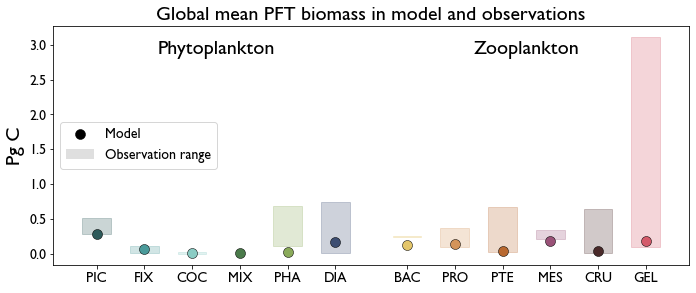

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

df = pd.read_csv('./data/phyto.csv')
df = df.dropna(subset=['species'])

# ============ EDITABLE PARAMETERS ============
label_fontsize = 20
tick_fontsize = 14
title_fontsize = 20
phyto_gap = 0.5  # extra space between phyto and zoo

phyto_species = ['PIC', 'FIX', 'COC', 'MIX', 'PHA', 'DIA']
zoo_species = ['BAC', 'PRO', 'PTE', 'MES', 'CRU', 'GEL']

species_colors = {
    'PIC': '#2d5a5a',
    'FIX': '#4a9a9a',
    'COC': '#8accc4',
    'MIX': '#4a7a4a',
    'PHA': '#8aaa5a',
    'DIA': '#3d4e72',
    'BAC': '#e4c66a',
    'PRO': '#d4945a',
    'PTE': '#b86830',
    'MES': '#9a5278',
    'GEL': '#d45a6a',
    'CRU': '#4a2a2a',
}
# ============================================

# Reorder df to match phyto then zoo
order = phyto_species + zoo_species
df = df.set_index('species').loc[order].reset_index()

# Parse observation ranges
obs_low = []
obs_high = []
for val in df['observations']:
    val = str(val).strip()
    if '-' in val and val != 'NaN':
        parts = val.split('-')
        obs_low.append(float(parts[0].strip()))
        obs_high.append(float(parts[1].strip()))
    else:
        obs_low.append(np.nan)
        obs_high.append(np.nan)
df['obs_low'] = obs_low
df['obs_high'] = obs_high

# X positions with gap between phyto and zoo
n_phyto = len(phyto_species)
x = np.arange(len(df), dtype=float)
x[n_phyto:] += phyto_gap

fact = 0.7
fig, ax = plt.subplots(figsize=(14*fact, 6*fact))
bar_width = 0.6

# Plot observation range as faded rectangles with species color
for i, (_, row) in enumerate(df.iterrows()):
    color = species_colors.get(row['species'], 'grey')
    if not np.isnan(row['obs_low']):
        ax.fill_between([x[i] - bar_width/2, x[i] + bar_width/2],
                        row['obs_low'], row['obs_high'],
                        color=color, alpha=0.25)

# Plot model as colored points
for i, (_, row) in enumerate(df.iterrows()):
    color = species_colors.get(row['species'], 'grey')
    ax.scatter(x[i], row['model'], color=color, zorder=5, s=100,
               edgecolors='black', linewidths=0.5)

# Legend
obs_patch = Patch(facecolor='grey', alpha=0.25, label='Observation range')
ax.scatter([], [], color='black', s=100, edgecolors='black', linewidths=0.5, label='Model')
ax.legend(handles=[ax.collections[-1], obs_patch], fontsize=tick_fontsize, loc='center left')

ax.set_xticks(x)
ax.set_xticklabels(df['species'], fontsize=tick_fontsize, fontweight='bold')
ax.set_ylabel('Pg C', fontsize=label_fontsize)
ax.tick_params(axis='y', labelsize=tick_fontsize)
ax.set_title('Global mean PFT biomass in model and observations', fontsize=title_fontsize)

# Group labels
ax.text(np.mean(x[:n_phyto]), ax.get_ylim()[1] * 0.88, 'Phytoplankton',
        ha='center', fontsize=label_fontsize, fontstyle='italic')
ax.text(np.mean(x[n_phyto:]), ax.get_ylim()[1] * 0.88, 'Zooplankton',
        ha='center', fontsize=label_fontsize, fontstyle='italic')

plt.tight_layout()
fig.savefig('./plts/POSTER/obs-abundance.jpg', dpi=300)
plt.show()

### shifts (from Fig-shift)

In [14]:
runs = [ 'TOM12_TJ_OBA1', 'TOM12_TJ_OBH1']
ds_hist, ds_hose = [xr.open_dataset(f'/gpfs/data/greenocean/users/mep22dku/clims/{run}/ORCA2_1m_clim_2010_2019_ptrc_T_int_rg.nc') 
                                for run in runs]

vars_phy = [
 'DIA',
 'MIX',
 'COC',
 'PIC',
 'PHA',
 'FIX']
vars_zoo =  [
 'BAC',
 'PRO',
 'PTE',
 'MES',
 'GEL',
'CRU',] 

vars_phy = ['PIC', 'FIX', 'COC', 'MIX', 'PHA', 'DIA']
vars_zoo = ['BAC', 'PRO', 'PTE', 'MES', 'CRU', 'GEL']


findfont: Font family ['cursive'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'cursive' not found because none of the following families were found: Apple Chancery, Textile, Zapf Chancery, Sand, Script MT, Felipa, Comic Neue, Comic Sans MS, cursive


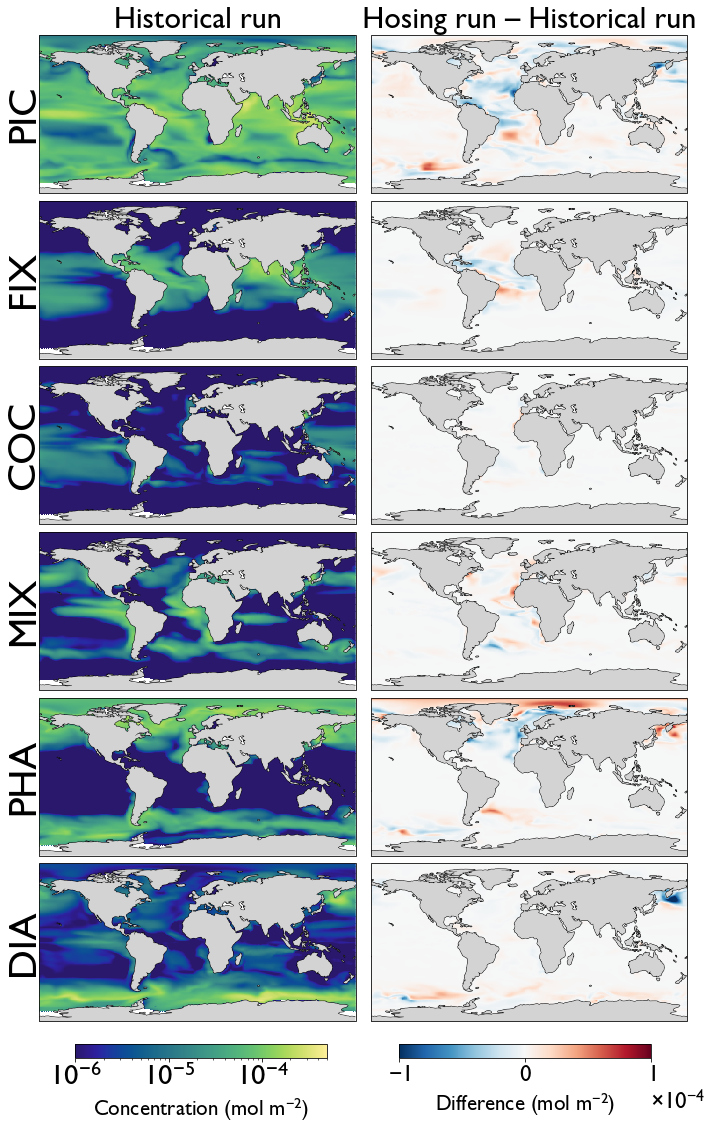

In [15]:
make = True
if make:
    
    import matplotlib.ticker as ticker

    # ============ EDITABLE PARAMETERS ============
    title_fontsize = 30
    label_fontsize = 35
    vmin_abs = 1e-6
    vmax_abs = 5e-4
    abs_max_diff = 1e-4
    cbar_aspect = 30
    hspace = 0.02
    wspace = 0.05
    # ============================================

    tvars = vars_phy

    # Preload into memory
    ds_hist_loaded = ds_hist[tvars].load()
    ds_hose_loaded = ds_hose[tvars].load()

    fig, axes = plt.subplots(6, 2, figsize=(10, 16),
                             subplot_kw={'projection': ccrs.PlateCarree()})
    data_crs = ccrs.PlateCarree()
    land = cfeature.NaturalEarthFeature('physical', 'land', '110m',
                                         edgecolor='none',
                                         facecolor='lightgrey')
    col_titles = ['Historical run', ' Hosing run \u2013 Historical run ']

    for i, var in enumerate(tvars):
        data_hist = ds_hist_loaded[var].mean(dim='time')
        data_hose = ds_hose_loaded[var].mean(dim='time')
        diff_hose =  data_hose - data_hist

        # Left column: absolute with log scale
        ax = axes[i, 0]
        im1 = data_hist.plot.pcolormesh(ax=ax, transform=data_crs,
                                  cmap=cm.haline,
                                  norm=LogNorm(vmin=vmin_abs, vmax=vmax_abs),
                                  add_colorbar=False)
        ax.add_feature(land, zorder=2)
        ax.coastlines()
        ax.set_global()
        if i == 0:
            ax.set_title(col_titles[0], fontsize=title_fontsize, fontweight='bold')
        else:
            ax.set_title('')

        ax.text(-0.045, 0.5, var, transform=ax.transAxes,
                fontsize=label_fontsize+5, fontweight='bold',
                rotation=90, va='center', ha='center')

        # Right column: difference
        ax = axes[i, 1]
        im2 = diff_hose.plot.pcolormesh(ax=ax, transform=data_crs,
                             cmap='RdBu_r',
                             vmin=-abs_max_diff, vmax=abs_max_diff,
                             add_colorbar=False)
        ax.add_feature(land, zorder=2)
        ax.coastlines()
        ax.set_global()
        if i == 0:
            ax.set_title(col_titles[1], fontsize=title_fontsize, fontweight='bold')
        else:
            ax.set_title('')

    plt.subplots_adjust(hspace=hspace, wspace=wspace, left=0.05, right=0.95, top=0.98, bottom=0.12)

    col1_center = 0.05 + (0.95 - 0.05) / 4
    col2_center = 0.05 + 3 * (0.95 - 0.05) / 4
    cbar_width = 0.35
    cbar_height = 0.012
    ty = 0.09

    cax1 = fig.add_axes([col1_center - cbar_width/2, ty, cbar_width, cbar_height])
    cbar1 = plt.colorbar(im1, cax=cax1, orientation='horizontal')
    cbar1.set_label('Concentration (mol m$^{-2}$)', fontsize=label_fontsize - 14)
    cbar1.ax.tick_params(labelsize=label_fontsize - 6)

    cax2 = fig.add_axes([col2_center - cbar_width/2, ty, cbar_width, cbar_height])
    cbar2 = plt.colorbar(im2, cax=cax2, orientation='horizontal')
    cbar2.set_label('Difference (mol m$^{-2}$)', fontsize=label_fontsize - 14)
    cbar2.ax.tick_params(labelsize=label_fontsize - 12)
    cbar2.ax.ticklabel_format(style='sci', scilimits=(-4, -4), useMathText=True)
    cbar2.update_ticks()
    cbar2.ax.xaxis.get_offset_text().set_fontsize(label_fontsize - 12)
    cbar2.ax.xaxis.get_offset_text().set_position((1.215, 0))

    plt.savefig('./plts/POSTER/POSTER-Fig_phyto_shift.jpg', dpi=300, bbox_inches='tight')
    plt.show()

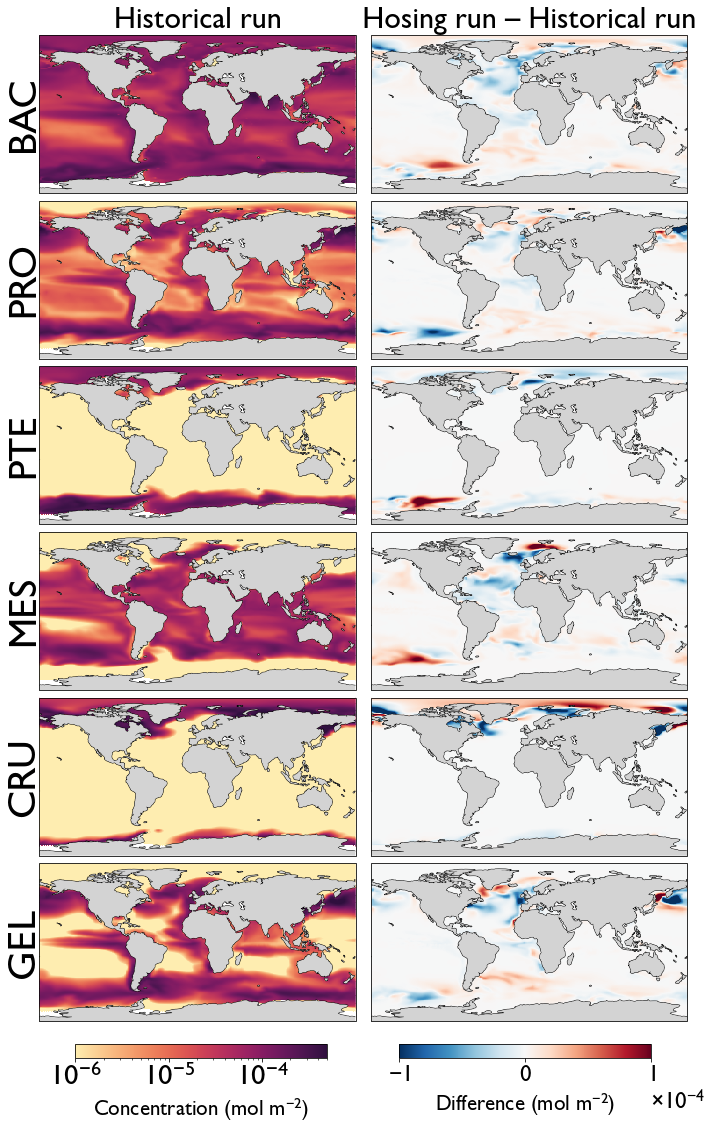

In [16]:
make = True
if make:
    
    import matplotlib.ticker as ticker

    # ============ EDITABLE PARAMETERS ============
    title_fontsize = 30
    label_fontsize = 35
    vmin_abs = 1e-6
    vmax_abs = 5e-4
    abs_max_diff = 1e-4
    cbar_aspect = 30
    hspace = 0.02
    wspace = 0.05
    # ============================================

    tvars = vars_zoo

    # Preload into memory
    ds_hist_loaded = ds_hist[tvars].load()
    ds_hose_loaded = ds_hose[tvars].load()

    fig, axes = plt.subplots(6, 2, figsize=(10, 16),
                             subplot_kw={'projection': ccrs.PlateCarree()})
    data_crs = ccrs.PlateCarree()
    land = cfeature.NaturalEarthFeature('physical', 'land', '110m',
                                         edgecolor='none',
                                         facecolor='lightgrey')
    col_titles = ['Historical run', ' Hosing run \u2013 Historical run ']

    for i, var in enumerate(tvars):
        data_hist = ds_hist_loaded[var].mean(dim='time')
        data_hose = ds_hose_loaded[var].mean(dim='time')
        diff_hose =  data_hose - data_hist

        # Left column: absolute with log scale
        ax = axes[i, 0]
        im1 = data_hist.plot.pcolormesh(ax=ax, transform=data_crs,
                                  cmap=cm.matter,
                                  norm=LogNorm(vmin=vmin_abs, vmax=vmax_abs),
                                  add_colorbar=False)
        ax.add_feature(land, zorder=2)
        ax.coastlines()
        ax.set_global()
        if i == 0:
            ax.set_title(col_titles[0], fontsize=title_fontsize, fontweight='bold')
        else:
            ax.set_title('')

        ax.text(-0.045, 0.5, var, transform=ax.transAxes,
                fontsize=label_fontsize+5, fontweight='bold',
                rotation=90, va='center', ha='center')

        # Right column: difference
        ax = axes[i, 1]
        im2 = diff_hose.plot.pcolormesh(ax=ax, transform=data_crs,
                             cmap='RdBu_r',
                             vmin=-abs_max_diff, vmax=abs_max_diff,
                             add_colorbar=False)
        ax.add_feature(land, zorder=2)
        ax.coastlines()
        ax.set_global()
        if i == 0:
            ax.set_title(col_titles[1], fontsize=title_fontsize, fontweight='bold')
        else:
            ax.set_title('')

    plt.subplots_adjust(hspace=hspace, wspace=wspace, left=0.05, right=0.95, top=0.98, bottom=0.12)

    col1_center = 0.05 + (0.95 - 0.05) / 4
    col2_center = 0.05 + 3 * (0.95 - 0.05) / 4
    cbar_width = 0.35
    cbar_height = 0.012
    ty = 0.09

    cax1 = fig.add_axes([col1_center - cbar_width/2, ty, cbar_width, cbar_height])
    cbar1 = plt.colorbar(im1, cax=cax1, orientation='horizontal')
    cbar1.set_label('Concentration (mol m$^{-2}$)', fontsize=label_fontsize - 14)
    cbar1.ax.tick_params(labelsize=label_fontsize - 6)

    cax2 = fig.add_axes([col2_center - cbar_width/2, ty, cbar_width, cbar_height])
    cbar2 = plt.colorbar(im2, cax=cax2, orientation='horizontal')
    cbar2.set_label('Difference (mol m$^{-2}$)', fontsize=label_fontsize - 14)
    cbar2.ax.tick_params(labelsize=label_fontsize - 12)
    cbar2.ax.ticklabel_format(style='sci', scilimits=(-4, -4), useMathText=True)
    cbar2.update_ticks()
    cbar2.ax.xaxis.get_offset_text().set_fontsize(label_fontsize - 12)
    cbar2.ax.xaxis.get_offset_text().set_position((1.215, 0))

    plt.savefig('./plts/POSTER/POSTER-Fig_zoo_shift.jpg', dpi=300, bbox_inches='tight')
    plt.show()

## get provincial means for different species

In [19]:
def calculate_province_means(ds, variables, provinces):
    """
    Calculate weighted spatial means over provinces for given variables.

    The province masks contain weights (cell sizes), so we compute:
    weighted_mean = sum(data * weights) / sum(weights)

    Parameters
    ----------
    ds : xr.Dataset
        Input dataset with variables
    variables : list of str
        List of variable names to process
    provinces : dict
        Dictionary of province_name: weight_mask pairs

    Returns
    -------
    pd.DataFrame
        DataFrame with columns: variable, province, value
    """
    results = []

    # Average over time dimension first
    ds_mean = ds.mean(dim='time')

    for var in variables:
        if var not in ds_mean:
            print(f"Warning: {var} not found in dataset")
            continue

        var_data = ds_mean[var]

        for prov_name, prov_mask in provinces.items():
            # Mask the data to the province (set values outside province to 0)
            masked_data = var_data.where(prov_mask > 0, 0)

            # Mask the weights to the province (set weights outside province to 0)
            masked_weights = prov_mask.where(prov_mask > 0, 0)

            # Get spatial dimensions (everything except time)
            spatial_dims = [d for d in masked_data.dims if d not in ['time_counter', 'time']]

            # Calculate weighted mean: sum(data * weights) / sum(weights)
            weighted_sum = (masked_data * masked_weights).sum(dim=spatial_dims)
            total_weight = masked_weights.sum(dim=spatial_dims)

            # Avoid division by zero
            if total_weight > 0:
                prov_mean = float((weighted_sum / total_weight).values)
            else:
                prov_mean = float('nan')

            results.append({
                'variable': var,
                'province': prov_name,
                'value': prov_mean
            })

    return pd.DataFrame(results)


ex = False
if ex:
    import xarray as xr
    import pandas as pd
    from pathlib import Path
    import numpy as np

    # Define runs
    runs = ['TOM12_TJ_OBA1',  'TOM12_TJ_OBH1']

    # Load datasets
    ds_hist, ds_hose = [xr.open_dataset(f'/gpfs/data/greenocean/users/mep22dku/clims/{run}/ORCA2_1m_clim_2010_2019_ptrc_T_int.nc') 
                                    for run in runs]

    datasets = { 'HIST': ds_hist, 'HOSE': ds_hose}

    # Load masks
    MA = xr.open_dataset('/gpfs/home/mep22dku/scratch/AMOC-PLANKTOM/AMOC-LoP-202510/data/mask_atl.nc')
    mask = xr.open_dataset('/gpfs/home/mep22dku/scratch/SOZONE/UTILS/mesh_mask3pt6_nicedims.nc')

    # Define provinces (these are the weights!)
    provinces = {
        'GO': mask.csize,
        'AB': mask.csize * MA.AB,
        'HA': mask.csize * MA.HA,
        'NA': mask.csize * MA.NA
    }

    # Define variables
    vars_phy = ['DIA', 'MIX', 'COC', 'PIC', 'PHA', 'FIX']
    vars_zoo = ['BAC', 'PRO', 'PTE', 'MES', 'GEL', 'CRU']

    # Create output directory
    output_dir = Path('./data')
    output_dir.mkdir(exist_ok=True)

    # Function to calculate province means with proper weighting



    # Process all datasets and store results
    all_results = {}

    for dataset_name, ds in datasets.items():
        print(f"\n{'='*60}")
        print(f"Processing {dataset_name}...")
        print(f"{'='*60}")

        # Calculate for phytoplankton
        df_phy = calculate_province_means(ds, vars_phy, provinces)
        df_phy['model'] = dataset_name
        all_results[f'{dataset_name}_phytoplankton'] = df_phy

        output_file = output_dir / f'{dataset_name}_phytoplankton_province_means.csv'
        df_phy.to_csv(output_file, index=False)
        print(f"Saved phytoplankton: {output_file}")
        #print(df_phy)

        # Calculate for zooplankton
        df_zoo = calculate_province_means(ds, vars_zoo, provinces)
        df_zoo['model'] = dataset_name
        all_results[f'{dataset_name}_zooplankton'] = df_zoo

        output_file = output_dir / f'{dataset_name}_zooplankton_province_means.csv'
        df_zoo.to_csv(output_file, index=False)
        print(f"Saved zooplankton: {output_file}")
        #print(df_zoo)

    print(f"\n{'='*60}")
    print("All datasets processed!")
    print(f"{'='*60}")

    # Combine all results
    df_all = pd.concat(all_results.values(), ignore_index=True)
    df_all.to_csv(output_dir / 'TESTall_province_means.csv', index=False)
    print(f"Combined results saved to: {output_dir / 'all_province_means.csv'}")


## this one! single-column, with total sum at bottom

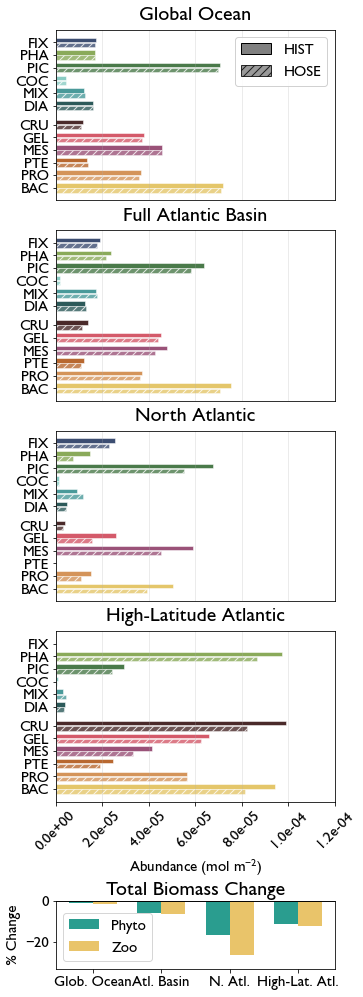

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

df = pd.read_csv('./data/TESTall_province_means.csv')
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
df['province'] = df['province'].fillna('NA')
df.columns = df.columns.str.strip()
df['variable'] = df['variable'].str.strip()
df['province'] = df['province'].str.strip()
df['model'] = df['model'].str.strip()

# ============ EDITABLE PARAMETERS ============
label_fontsize = 15
tick_fontsize = 15
title_fontsize = 20
bar_height = 0.35
bar_offset = 0.2
bar_spacing = 1.0
gap = 1.5
xmax = 1.2e-4
ticks = np.array([0, 2, 4, 6, 8, 10, 12]) * 1e-5
phyto_color = '#2a9d8f'
zoo_color = '#e9c46a'

## PLAY WITH THESE to control spacing
top_hspace = 0.2        # vertical spacing between the top 4 plots (smaller = tighter)
bottom_nudge = 0.06     # how far to push the bottom plot down (bigger = more gap)

phyto_species = ['DIA', 'MIX', 'COC', 'PIC', 'PHA', 'FIX']
zoo_species = ['BAC', 'PRO', 'PTE', 'MES', 'GEL', 'CRU']

species_colors = {
    'DIA': '#2d5a5a',
    'MIX': '#4a9a9a',
    'COC': '#8accc4',
    'PIC': '#4a7a4a',
    'PHA': '#8aaa5a',
    'FIX': '#3d4e72',
    'BAC': '#e4c66a',
    'PRO': '#d4945a',
    'PTE': '#b86830',
    'MES': '#9a5278',
    'GEL': '#d45a6a',
    'CRU': '#4a2a2a',
}

province_names = {
    'GO': 'Global Ocean',
    'AB': 'Full Atlantic Basin',
    'NA': 'North Atlantic',
    'HA': 'High-Latitude Atlantic',
}

provinces = ['GO', 'AB', 'NA', 'HA']
# ============================================

all_species = phyto_species + zoo_species
n_phyto = len(phyto_species)
n_zoo = len(zoo_species)

y_zoo = np.arange(n_zoo) * bar_spacing
y_phyto = np.arange(n_phyto) * bar_spacing + y_zoo[-1] + gap
y_all = np.concatenate([y_phyto, y_zoo])
colors = [species_colors[s] for s in all_species]

fig = plt.figure(figsize=(5, 16))
gs = fig.add_gridspec(5, 1, height_ratios=[1, 1, 1, 1, 0.4],
                      hspace=top_hspace)

for idx, province in enumerate(provinces):
    ax = fig.add_subplot(gs[idx, 0])

    prov = df[df['province'] == province]
    hist = prov[prov['model'] == 'HIST'].set_index('variable')['value']
    hose = prov[prov['model'] == 'HOSE'].set_index('variable')['value']
    common = hist.index.intersection(hose.index)
    hist = hist.loc[common]
    hose = hose.loc[common]

    ax.barh(y_all + bar_offset, hist[all_species].values, height=bar_height,
            color=colors, edgecolor='white', linewidth=0.5, align='center')
    ax.barh(y_all - bar_offset, hose[all_species].values, height=bar_height,
            color=colors, edgecolor='white', linewidth=0.5, align='center',
            hatch='///', alpha=0.8)

    ax.set_yticks(y_all)
    ax.set_yticklabels(all_species, fontsize=tick_fontsize, fontweight='bold')
    ax.set_xlim(0, xmax)
    ax.set_xticks(ticks)
    ax.grid(axis='x', alpha=0.3)
    ax.set_title(province_names[province], fontsize=title_fontsize,
                 fontweight='bold', pad=10)

    if idx < 3:
        ax.set_xticklabels([])
        ax.tick_params(axis='x', length=0)
    else:
        ax.set_xticklabels([f'{t:.1e}' for t in ticks], fontsize=tick_fontsize)
        ax.tick_params(axis='x', rotation=45)
        ax.set_xlabel('Abundance (mol m$^{-2}$)', fontsize=label_fontsize)

    if idx == 0:
        hist_patch = mpatches.Patch(facecolor='grey', edgecolor='black', label='HIST')
        hose_patch = mpatches.Patch(facecolor='grey', edgecolor='black', hatch='///', alpha=0.8, label='HOSE')
        ax.legend(handles=[hist_patch, hose_patch], fontsize=tick_fontsize,
                  loc='upper right', framealpha=0.9)

# --- Bottom row: % change ---
ax_pct = fig.add_subplot(gs[4, 0])

province_names = {
    'GO': 'Glob. Ocean',
    'AB': 'Atl. Basin',
    'NA': 'N. Atl.',
    'HA': 'High-Lat. Atl.',
}


phyto_pct = []
zoo_pct = []
for province in provinces:
    prov = df[df['province'] == province]
    hist = prov[prov['model'] == 'HIST'].set_index('variable')['value']
    hose = prov[prov['model'] == 'HOSE'].set_index('variable')['value']

    hist_phyto = hist[phyto_species].sum()
    hose_phyto = hose[phyto_species].sum()
    phyto_pct.append((hose_phyto - hist_phyto) / hist_phyto * 100)

    hist_zoo = hist[zoo_species].sum()
    hose_zoo = hose[zoo_species].sum()
    zoo_pct.append((hose_zoo - hist_zoo) / hist_zoo * 100)

x = np.arange(len(provinces))
pct_bar_width = 0.35

ax_pct.bar(x - pct_bar_width/2, phyto_pct, pct_bar_width, color=phyto_color, label='Phyto')
ax_pct.bar(x + pct_bar_width/2, zoo_pct, pct_bar_width, color=zoo_color, label='Zoo')
ax_pct.axhline(0, color='black', linewidth=0.8)
ax_pct.set_xticks(x)
ax_pct.set_xticklabels([province_names[p] for p in provinces], fontsize=tick_fontsize-2, fontweight='bold')
ax_pct.set_ylabel('% Change', fontsize=label_fontsize)
ax_pct.set_title('Total Biomass Change', fontsize=title_fontsize, fontweight='bold')
ax_pct.tick_params(axis='both', labelsize=tick_fontsize)
ax_pct.legend(fontsize=tick_fontsize, loc='lower left')
#ax_pct.grid(axis='y', alpha=0.3)
ax_pct.set_ylim([-33,0])

# for i in range(len(provinces)):
#     ax_pct.text(x[i] - pct_bar_width/2, phyto_pct[i] + (0.5 if phyto_pct[i] >= 0 else -3.5),
#                 f'{phyto_pct[i]:.1f}%', ha='center', fontsize=tick_fontsize - 3)
#     ax_pct.text(x[i] + pct_bar_width/2, zoo_pct[i] + (0.5 if zoo_pct[i] >= 0 else -3.5),
#                 f'{zoo_pct[i]:.1f}%', ha='center', fontsize=tick_fontsize - 3)

plt.tight_layout()

# Nudge bottom plot down to avoid overlapping the abundance label
pos = ax_pct.get_position()
ax_pct.set_position([pos.x0, pos.y0 - bottom_nudge, pos.width, pos.height])

fig.savefig('./plts/POSTER/paired_bars_column.jpg', dpi=300, bbox_inches='tight')
plt.show()

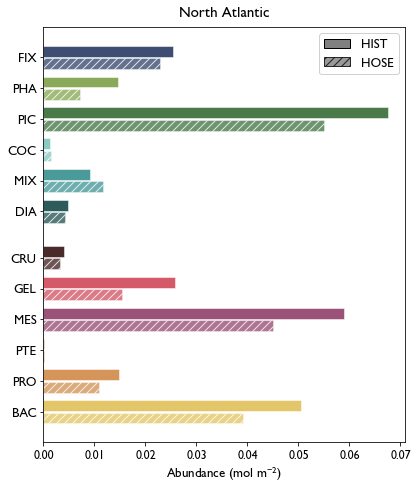

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from matplotlib import font_manager, rcParams
import os

# ================================
# FONT CONFIGURATION
# ================================
plt.rcParams['text.usetex'] = False
fs = 13
gill_sans_path = "/gpfs/home/mep22dku/scratch/FONTS/gill-sans/GillSansMedium.otf"
if os.path.exists(gill_sans_path):
    font_manager.fontManager.addfont(gill_sans_path)
    chosen_font = font_manager.FontProperties(fname=gill_sans_path).get_name()
else:
    chosen_font = "DejaVu Sans"
rcParams.update({
    'font.size': fs, 'font.family': chosen_font,
    'axes.titlesize': fs, 'axes.labelsize': fs,
    'xtick.labelsize': fs-1, 'ytick.labelsize': fs-1,
})

# ================================
# SETTABLE
# ================================
bar_height  = 0.35
bar_offset  = 0.2
bar_spacing = 1.0
gap         = 1.5
xmax        = 1.2e-4
ticks       = np.array([0, 2, 4, 6, 8, 10, 12]) * 1e-5

phyto_species = ['DIA', 'MIX', 'COC', 'PIC', 'PHA', 'FIX']
zoo_species   = ['BAC', 'PRO', 'PTE', 'MES', 'GEL', 'CRU']

species_colors = {
    'DIA': '#2d5a5a', 'MIX': '#4a9a9a', 'COC': '#8accc4',
    'PIC': '#4a7a4a', 'PHA': '#8aaa5a', 'FIX': '#3d4e72',
    'BAC': '#e4c66a', 'PRO': '#d4945a', 'PTE': '#b86830',
    'MES': '#9a5278', 'GEL': '#d45a6a', 'CRU': '#4a2a2a',
}

# ================================
# LOAD DATA
# ================================
df = pd.read_csv('./data/TESTall_province_means.csv', keep_default_na=False)
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
df.columns     = df.columns.str.strip()
df['variable'] = df['variable'].str.strip()
df['province'] = df['province'].str.strip()
df['model']    = df['model'].str.strip()

prov = df[df['province'] == 'NA']
hist = prov[prov['model'] == 'HIST'].set_index('variable')['value']
hose = prov[prov['model'] == 'HOSE'].set_index('variable')['value']
hist = hist * 1000
hose = hose * 1000
# ================================
# Y POSITIONS
# ================================
all_species = phyto_species + zoo_species
y_zoo   = np.arange(len(zoo_species)) * bar_spacing
y_phyto = np.arange(len(phyto_species)) * bar_spacing + y_zoo[-1] + gap
y_all   = np.concatenate([y_phyto, y_zoo])
colors  = [species_colors[s] for s in all_species]

# ================================
# PLOT
# ================================
fig, ax = plt.subplots(figsize=(6, 7))

ax.barh(y_all + bar_offset, hist[all_species].values, height=bar_height,
        color=colors, edgecolor='white', linewidth=0.5, align='center')
ax.barh(y_all - bar_offset, hose[all_species].values, height=bar_height,
        color=colors, edgecolor='white', linewidth=0.5, align='center',
        hatch='///', alpha=0.8)

ax.set_yticks(y_all)
ax.set_yticklabels(all_species, fontsize=fs, fontweight='bold')
#ax.set_xlim(0, xmax)
#ax.set_xticks(ticks)
#ax.set_xticklabels([f'{t:.1e}' for t in ticks], fontsize=fs-1, rotation=45)
ax.set_xlabel('Abundance (mol m$^{-2}$)', fontsize=fs)
ax.set_title('North Atlantic', fontsize=fs+2, fontweight='bold', pad=10)
#ax.grid(axis='x', alpha=0.3)

hist_patch = mpatches.Patch(facecolor='grey', edgecolor='black', label='HIST')
hose_patch = mpatches.Patch(facecolor='grey', edgecolor='black', hatch='///', alpha=0.8, label='HOSE')
ax.legend(handles=[hist_patch, hose_patch], fontsize=fs, loc='upper right', framealpha=0.9)

plt.tight_layout()
os.makedirs('./plts', exist_ok=True)
plt.savefig('./plts/NA_paired_bars.png', dpi=300, bbox_inches='tight')
plt.show()

## stacked bg

,variable,province,value,model
0,DIA,GO,0.000016,HIST
1,DIA,AB,0.000012,HIST
2,DIA,HA,0.000004,HIST
3,DIA,NaN,0.000005,HIST
4,MIX,GO,0.000012,HIST
...,...,...,...,...
91,GEL,NaN,0.000015,HOSE
92,CRU,GO,0.000011,HOSE
93,CRU,AB,0.000011,HOSE
94,CRU,HA,0.000082,HOSE


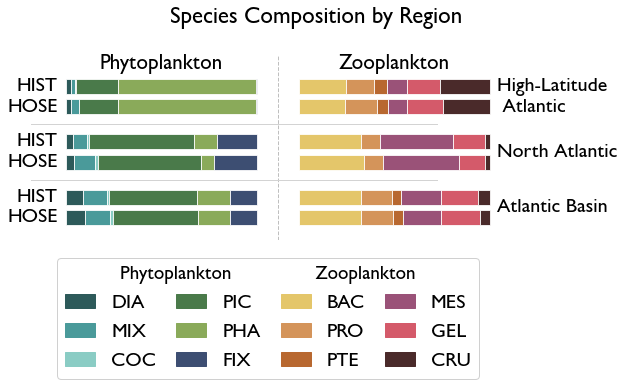

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

df = pd.read_csv('./data/TESTall_province_means.csv')
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
df['province'] = df['province'].fillna('NA')
df.columns = df.columns.str.strip()
df['variable'] = df['variable'].str.strip()
df['province'] = df['province'].str.strip()
df['model'] = df['model'].str.strip()

# ============ EDITABLE PARAMETERS ============
label_fontsize = 20
tick_fontsize  = 20
title_fontsize = 20
bar_height     = 0.32
gap_phyto_zoo  = 0.22   # horizontal gap between phyto and zoo bars
province_gap   = 0.3    # extra vertical gap between province blocks

phyto_species = ['DIA', 'MIX', 'COC', 'PIC', 'PHA', 'FIX']
zoo_species   = ['BAC', 'PRO', 'PTE', 'MES', 'GEL', 'CRU']

phyto_colors = {
    'DIA': '#2d5a5a', 'MIX': '#4a9a9a', 'COC': '#8accc4',
    'PIC': '#4a7a4a', 'PHA': '#8aaa5a', 'FIX': '#3d4e72',
}
zoo_colors = {
    'BAC': '#e4c66a', 'PRO': '#d4945a', 'PTE': '#b86830',
    'MES': '#9a5278', 'GEL': '#d45a6a', 'CRU': '#4a2a2a',
}

provinces = ['HA', 'NA', 'AB']
province_labels = {
    'HA': 'High-Latitude \n Atlantic',
    'NA': 'North Atlantic',
    'AB': 'Atlantic Basin',
}
# ============================================

def get_fractions(values, species):
    vals = np.array([values.get(s, 0) for s in species], dtype=float)
    total = vals.sum()
    return vals / total if total > 0 else vals

def draw_stacked_bar(ax, y, fractions, species, colors_dict, x_offset=0.0):
    left = x_offset
    for frac, sp in zip(fractions, species):
        ax.barh(y, frac, left=left, height=bar_height,
                color=colors_dict[sp], edgecolor='white', linewidth=0.8,
                align='center')
        left += frac

# --- Build y positions ---
# Each province = 2 rows (HIST, HOSE), separated by bar_height spacing
# Provinces separated by an extra gap
# We go top-down: highest y = top province HIST

row_spacing = bar_height + 0.12   # vertical distance between HIST and HOSE rows
block_height = 2 * row_spacing     # height of one province block

y_positions = {}   # {province: (y_hist, y_hose)}
y_top = 0.0
for prov in provinces:
    y_hist = y_top
    y_hose = y_top - row_spacing
    y_positions[prov] = (y_hist, y_hose)
    y_top = y_hose - row_spacing - province_gap

phyto_offset = 0.0
zoo_offset   = 1.0 + gap_phyto_zoo

# --- Figure ---
fig_height = len(provinces) * (block_height + province_gap) + 1.8  # extra for legend
fig, ax = plt.subplots(figsize=(9, fig_height))

for prov in provinces:
    prov_df = df[df['province'] == prov]
    hist = prov_df[prov_df['model'] == 'HIST'].set_index('variable')['value']
    hose = prov_df[prov_df['model'] == 'HOSE'].set_index('variable')['value']

    hist_phyto = get_fractions(hist, phyto_species)
    hose_phyto = get_fractions(hose, phyto_species)
    hist_zoo   = get_fractions(hist, zoo_species)
    hose_zoo   = get_fractions(hose, zoo_species)

    y_hist, y_hose = y_positions[prov]

    # Draw bars
    draw_stacked_bar(ax, y_hist, hist_phyto, phyto_species, phyto_colors, phyto_offset)
    draw_stacked_bar(ax, y_hose, hose_phyto, phyto_species, phyto_colors, phyto_offset)
    draw_stacked_bar(ax, y_hist, hist_zoo,   zoo_species,   zoo_colors,   zoo_offset)
    draw_stacked_bar(ax, y_hose, hose_zoo,   zoo_species,   zoo_colors,   zoo_offset)

    # HIST / HOSE row labels
    ax.text(-0.04, y_hist, 'HIST', ha='right', va='center',
            fontsize=tick_fontsize, fontweight='bold')
    ax.text(-0.04, y_hose, 'HOSE', ha='right', va='center',
            fontsize=tick_fontsize, fontweight='bold')

    # Province label on the right
    y_mid = (y_hist + y_hose) / 2
    ax.text(zoo_offset + 1.04, y_mid, province_labels[prov],
            ha='left', va='center', fontsize=label_fontsize, fontweight='bold',
            rotation=0)

# Column titles above the very top bars
y_top_hist = y_positions[provinces[0]][0]
ax.text(phyto_offset + 0.5, y_top_hist + bar_height * 0.85, 'Phytoplankton',
        ha='center', va='bottom', fontsize=title_fontsize + 1, fontweight='bold')
ax.text(zoo_offset + 0.5, y_top_hist + bar_height * 0.85, 'Zooplankton',
        ha='center', va='bottom', fontsize=title_fontsize + 1, fontweight='bold')

# Vertical divider between phyto and zoo
mid_x = phyto_offset + 1.0 + gap_phyto_zoo / 2
y_bottom_hose = y_positions[provinces[-1]][1]
ax.axvline(mid_x, color='grey', linewidth=1, linestyle='--', alpha=0.5,
           ymin=0, ymax=1)

# Horizontal dividers between provinces
for i in range(1, len(provinces)):
    prev_hose = y_positions[provinces[i-1]][1]
    curr_hist = y_positions[provinces[i]][0]
    y_div = (prev_hose + curr_hist) / 2
    ax.axhline(y_div, xmin=0, xmax=0.72, color='lightgrey',
               linewidth=1, linestyle='-')

# --- Single combined legend at the bottom ---
all_patches = (
    [mpatches.Patch(color=phyto_colors[s], label=s) for s in phyto_species] +
    [mpatches.Patch(color=zoo_colors[s],   label=s) for s in zoo_species]
)
ax.legend(handles=all_patches, loc='upper center',
          bbox_to_anchor=(0.42, -0.04),
          ncol=4, fontsize=tick_fontsize,
          framealpha=0.9, columnspacing=1.0, handlelength=1.5,
          title='Phytoplankton                Zooplankton',
          title_fontsize=tick_fontsize - 1)

# --- Axes cleanup ---
y_lo = y_bottom_hose - bar_height * 1.5
y_hi = y_top_hist + bar_height * 2.0
ax.set_xlim(-0.18, zoo_offset + 1.55)
ax.set_ylim(y_lo, y_hi)
ax.set_yticks([])
ax.set_xticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

fig.suptitle('Species Composition by Region',
             fontsize=title_fontsize + 3, fontweight='bold', y=1.01)

plt.tight_layout()
plt.savefig('./plts/POSTER/composition_bars_3prov.jpg', dpi=300, bbox_inches='tight')
plt.show()

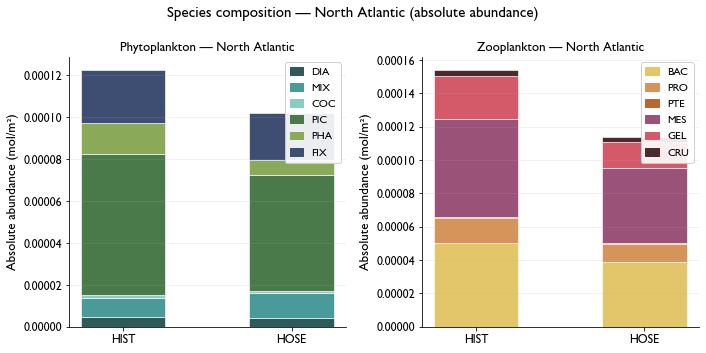

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager, rcParams
import matplotlib.patches as mpatches
import os

# ================================
# FONT CONFIGURATION
# ================================
plt.rcParams['text.usetex'] = False
fs = 13
gill_sans_path = "/gpfs/home/mep22dku/scratch/FONTS/gill-sans/GillSansMedium.otf"
if os.path.exists(gill_sans_path):
    font_manager.fontManager.addfont(gill_sans_path)
    chosen_font = font_manager.FontProperties(fname=gill_sans_path).get_name()
else:
    chosen_font = "DejaVu Sans"
rcParams.update({
    'font.size': fs, 'font.family': chosen_font,
    'axes.titlesize': fs, 'axes.labelsize': fs,
    'xtick.labelsize': fs-1, 'ytick.labelsize': fs-1,
})

# ================================
# SETTABLE
# ================================
phyto_species = ['DIA', 'MIX', 'COC', 'PIC', 'PHA', 'FIX']
zoo_species   = ['BAC', 'PRO', 'PTE', 'MES', 'GEL', 'CRU']

phyto_colors = {
    'DIA': '#2d5a5a', 'MIX': '#4a9a9a', 'COC': '#8accc4',
    'PIC': '#4a7a4a', 'PHA': '#8aaa5a', 'FIX': '#3d4e72',
}
zoo_colors = {
    'BAC': '#e4c66a', 'PRO': '#d4945a', 'PTE': '#b86830',
    'MES': '#9a5278', 'GEL': '#d45a6a', 'CRU': '#4a2a2a',
}

# ================================
# LOAD DATA
# ================================
df = pd.read_csv('./data/TESTall_province_means.csv', keep_default_na=False)
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
df.columns      = df.columns.str.strip()
df['variable']  = df['variable'].str.strip()
df['province']  = df['province'].str.strip()
df['model']     = df['model'].str.strip()

na   = df[df['province'] == 'NA']
hist = na[na['model'] == 'HIST'].set_index('variable')['value']
hose = na[na['model'] == 'HOSE'].set_index('variable')['value']

# ================================
# PLOT
# ================================
fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=False)

def stacked_bars(ax, species, colors, title):
    models     = ['HIST', 'HOSE']
    data       = {'HIST': hist, 'HOSE': hose}
    x          = np.arange(len(models))
    bottom     = np.zeros(len(models))

    for sp in species:
        vals = np.array([data[m].get(sp, 0) for m in models])
        ax.bar(x, vals, bottom=bottom, color=colors[sp], label=sp,
               edgecolor='white', linewidth=0.6, width=0.5)
        bottom += vals

    ax.set_xticks(x)
    ax.set_xticklabels(models)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Absolute abundance (mol/m²)')
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    ax.grid(axis='y', alpha=0.3, linewidth=0.5)

stacked_bars(axes[0], phyto_species, phyto_colors, 'Phytoplankton — North Atlantic')
stacked_bars(axes[1], zoo_species,   zoo_colors,   'Zooplankton — North Atlantic')

# --- Legends ---
for ax, species, colors in [(axes[0], phyto_species, phyto_colors),
                             (axes[1], zoo_species,   zoo_colors)]:
    handles = [mpatches.Patch(color=colors[s], label=s) for s in species]
    ax.legend(handles=handles, fontsize=fs-2, framealpha=0.9,
              loc='upper right', handlelength=1.2)

fig.suptitle('Species composition — North Atlantic (absolute abundance)',
             fontsize=fs+2, fontweight='bold')
plt.tight_layout()
os.makedirs('./plts', exist_ok=True)
plt.savefig('./plts/NA_stacked_bars.png', dpi=300, bbox_inches='tight')
plt.show()

,variable,province,value,model


### ppt, cflx, etc

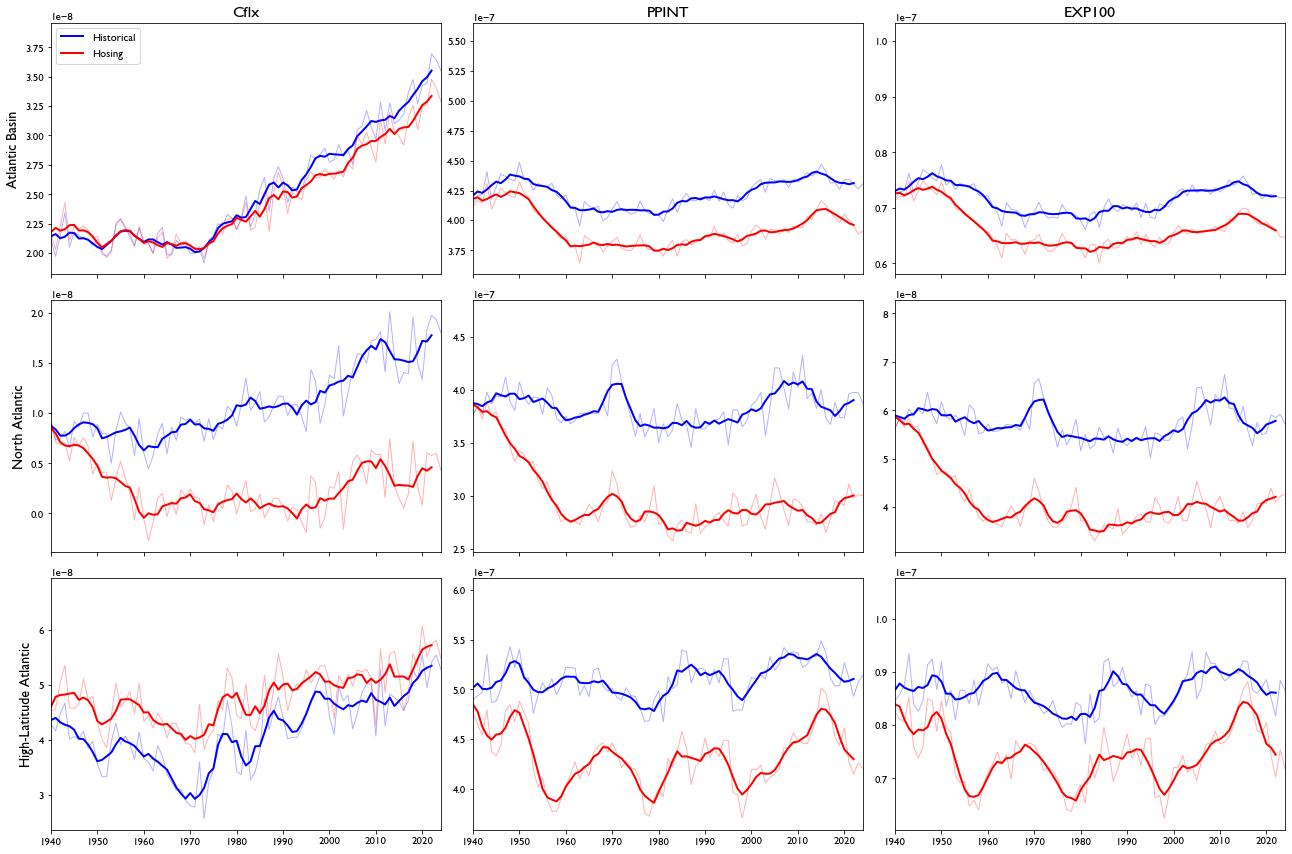

In [22]:
import xarray as xr
import matplotlib.pyplot as plt

base_oba = '/gpfs/data/greenocean/users/mep22dku/clims/TOM12_TJ_OBA1'
base_obh = '/gpfs/data/greenocean/users/mep22dku/clims/TOM12_TJ_OBH1'

OBA_cflx = xr.open_dataset(f'{base_oba}/TOM12_TJ_OBA1_diad_Cflx_dNone_provinces.nc')
OBH_cflx = xr.open_dataset(f'{base_obh}/TOM12_TJ_OBH1_diad_Cflx_dNone_provinces.nc')
OBA_pp = xr.open_dataset(f'{base_oba}/TOM12_TJ_OBA1_diad_PPINT_dNone_provinces.nc')
OBH_pp = xr.open_dataset(f'{base_obh}/TOM12_TJ_OBH1_diad_PPINT_dNone_provinces.nc')
OBA_exp = xr.open_dataset(f'{base_oba}/TOM12_TJ_OBA1_diad_EXP100_dNone_provinces.nc')
OBH_exp = xr.open_dataset(f'{base_obh}/TOM12_TJ_OBH1_diad_EXP100_dNone_provinces.nc')

# ============ EDITABLE PARAMETERS ============
label_fontsize = 14
tick_fontsize = 11
title_fontsize = 16
legend_fontsize = 11
# ============================================

province_names = {'AB': 'Atlantic Basin', 'NA': 'North Atlantic', 'HA': 'High-Latitude Atlantic'}
provinces = ['AB', 'NA', 'HA']

datasets = [
    (OBA_cflx, OBH_cflx, 'Cflx', 'Cflx'),
    (OBA_pp, OBH_pp, 'PPINT', 'PPINT'),
    (OBA_exp, OBH_exp, 'EXP', 'EXP100'),
]

fig, axes = plt.subplots(3, 3, figsize=(18, 12), sharex=True)

for col, (ds_oba, ds_obh, varname, col_title) in enumerate(datasets):
    for row, prov in enumerate(provinces):
        ax = axes[row, col]

        oba_yr = ds_oba[varname].sel(province=prov).groupby('time_counter.year').mean()
        obh_yr = ds_obh[varname].sel(province=prov).groupby('time_counter.year').mean()

        oba_5yr = oba_yr.rolling(year=5, center=True).mean()
        obh_5yr = obh_yr.rolling(year=5, center=True).mean()

        ax.plot(oba_yr.year, oba_yr, linewidth=1, color='b', alpha=0.3)
        ax.plot(oba_yr.year, oba_5yr, linewidth=2, color='b', label='Historical')
        ax.plot(obh_yr.year, obh_yr, linewidth=1, color='r', alpha=0.3)
        ax.plot(obh_yr.year, obh_5yr, linewidth=2, color='r', label='Hosing')

        ax.set_xlim(1940, 2024)
        ax.tick_params(axis='both', labelsize=tick_fontsize)

        if row == 0:
            ax.set_title(col_title, fontsize=title_fontsize, fontweight='bold')
        if col == 0:
            ax.set_ylabel(province_names[prov], fontsize=label_fontsize, fontweight='bold')
        if row == 0 and col == 0:
            ax.legend(fontsize=legend_fontsize)

plt.tight_layout()
plt.show()

## maps ppt, biomass 

## biomass

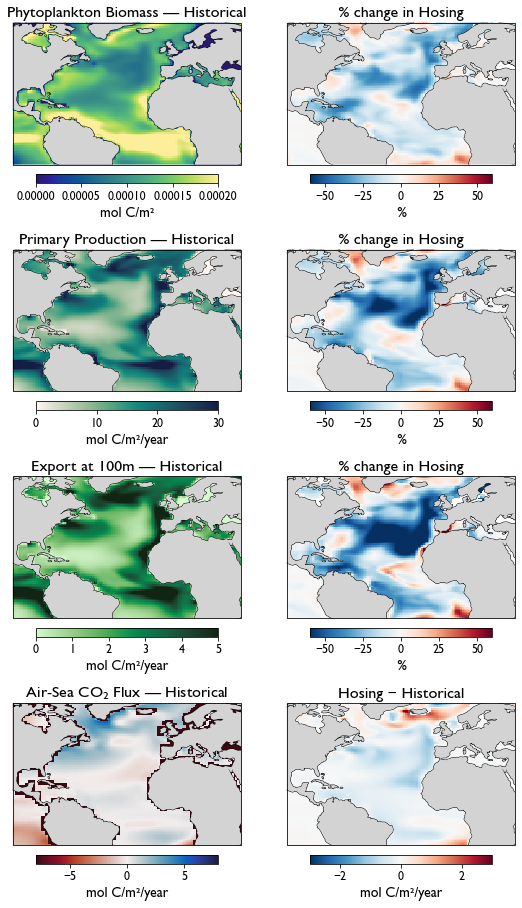

In [23]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import cmocean.cm as cm

bdir = '/gpfs/data/greenocean/users/mep22dku/clims/'
BASE = 'TOM12_TJ_OBA1'
HOSE = 'TOM12_TJ_OBH1'
BASE_diad = xr.open_dataset(f'{bdir}/{BASE}/ORCA2_1m_clim_2010_2019_diad_T_rg.nc')
HOSE_diad = xr.open_dataset(f'{bdir}/{HOSE}/ORCA2_1m_clim_2010_2019_diad_T_rg.nc')
BASE_diad['time'] = np.arange(1, 13, 1)
HOSE_diad['time'] = np.arange(1, 13, 1)

BASE_ptrc = xr.open_dataset(f'{bdir}/{BASE}/ORCA2_1m_clim_2010_2019_ptrc_T_int_rg.nc')
HOSE_ptrc = xr.open_dataset(f'{bdir}/{HOSE}/ORCA2_1m_clim_2010_2019_ptrc_T_int_rg.nc')

BASE_ptrc['PHY'] = BASE_ptrc['DIA'] + BASE_ptrc['MIX'] + BASE_ptrc['COC'] + \
                    BASE_ptrc['PHA'] + BASE_ptrc['PIC'] + BASE_ptrc['FIX']
HOSE_ptrc['PHY'] = HOSE_ptrc['DIA'] + HOSE_ptrc['MIX'] + HOSE_ptrc['COC'] + \
                    HOSE_ptrc['PHA'] + HOSE_ptrc['PIC'] + HOSE_ptrc['FIX']

days_per_month = [31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]
seconds_per_month = np.array(days_per_month) * 24 * 60 * 60
seconds_per_month_xr = xr.DataArray(seconds_per_month, dims=['time'])

BASE_diad['EXP100'] = (BASE_diad.EXP[:, 9, :, :] + BASE_diad.EXP[:, 10, :, :]) / 2
HOSE_diad['EXP100'] = (HOSE_diad.EXP[:, 9, :, :] + HOSE_diad.EXP[:, 10, :, :]) / 2

for var in ['EXP100', 'PPINT', 'Cflx']:
    BASE_diad[var][:, :, 79] = BASE_diad[var][:, :, 80].values
    HOSE_diad[var][:, :, 79] = HOSE_diad[var][:, :, 80].values

# ============ EDITABLE PARAMETERS ============
title_fontsize = 16
label_fontsize = 14
tick_fontsize = 12

lon_min = -100
lon_max = 40
lat_min = -17
lat_max = 70

phy_vmin = 0
phy_vmax = 2e-4
ppint_vmin = 0
ppint_vmax = 30
exp_vmin = 0
exp_vmax = 5
cflx_vmin = -8
cflx_vmax = 8

phy_pct_max = 60
ppint_pct_max = 60
exp_pct_max = 60
cflx_diff_max = 3
# ============================================

proj = ccrs.PlateCarree()
land = cfeature.NaturalEarthFeature('physical', 'land', '110m',
                                     edgecolor='none', facecolor='lightgrey')

lats = BASE_diad.lat.values
lons = BASE_diad.lon.values

fig, axes = plt.subplots(4, 2, figsize=(9, 16),
                         subplot_kw={'projection': proj})

# --- Row 0: PHY ---
base_phy = BASE_ptrc['PHY'].mean(dim='time')
hose_phy = HOSE_ptrc['PHY'].mean(dim='time')
diff_phy = ((hose_phy - base_phy) / base_phy.where(base_phy != 0)) * 100

ax = axes[0, 0]
im = ax.pcolormesh(lons, lats, base_phy, transform=proj,
                    vmin=phy_vmin, vmax=phy_vmax, cmap=cm.haline)
ax.coastlines()
ax.add_feature(land, zorder=2)
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ax.set_title('Phytoplankton Biomass — Historical', fontsize=title_fontsize, fontweight='bold')
cbar = plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.05, shrink=0.8)
cbar.set_label('mol C/m²', fontsize=label_fontsize)
cbar.ax.tick_params(labelsize=tick_fontsize)

ax = axes[0, 1]
im = ax.pcolormesh(lons, lats, diff_phy, transform=proj,
                    vmin=-phy_pct_max, vmax=phy_pct_max, cmap='RdBu_r')
ax.coastlines()
ax.add_feature(land, zorder=2)
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ax.set_title('% change in Hosing', fontsize=title_fontsize, fontweight='bold')
cbar = plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.05, shrink=0.8)
cbar.set_label('%', fontsize=label_fontsize)
cbar.ax.tick_params(labelsize=tick_fontsize)

# --- Rows 1-3: PPINT, EXP100, Cflx ---
metrics = ['PPINT', 'EXP100', 'Cflx']
metric_labels = ['Primary Production', 'Export at 100m', 'Air-Sea CO$_2$ Flux']
metric_units = ['mol C/m²/year', 'mol C/m²/year', 'mol C/m²/year']
abs_cmaps = [cm.tempo, cm.algae, cm.balance_r]
abs_vlims = [(ppint_vmin, ppint_vmax), (exp_vmin, exp_vmax), (cflx_vmin, cflx_vmax)]
diff_vlims = [ppint_pct_max, exp_pct_max, cflx_diff_max]
use_pct = [True, True, False]

for i, (metric, label, unit) in enumerate(zip(metrics, metric_labels, metric_units)):
    base_yearly = (BASE_diad[metric] * seconds_per_month_xr).sum(dim='time')
    hose_yearly = (HOSE_diad[metric] * seconds_per_month_xr).sum(dim='time')

    if use_pct[i]:
        diff_yearly = ((hose_yearly - base_yearly) / base_yearly.where(base_yearly != 0)) * 100
        diff_label = f'% change in Hosing'
        diff_unit = '%'
    else:
        diff_yearly = hose_yearly - base_yearly
        diff_label = f'Hosing − Historical'
        diff_unit = unit

    vmin_abs, vmax_abs = abs_vlims[i]
    dmax = diff_vlims[i]

    ax = axes[i + 1, 0]
    im1 = ax.pcolormesh(lons, lats, base_yearly, transform=proj,
                         vmin=vmin_abs, vmax=vmax_abs, cmap=abs_cmaps[i])
    ax.coastlines()
    ax.add_feature(land, zorder=2)
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
    ax.set_title(f'{label} — Historical', fontsize=title_fontsize, fontweight='bold')
    cbar = plt.colorbar(im1, ax=ax, orientation='horizontal', pad=0.05, shrink=0.8)
    cbar.set_label(unit, fontsize=label_fontsize)
    cbar.ax.tick_params(labelsize=tick_fontsize)

    ax = axes[i + 1, 1]
    im2 = ax.pcolormesh(lons, lats, diff_yearly, transform=proj,
                         vmin=-dmax, vmax=dmax, cmap='RdBu_r')
    ax.coastlines()
    ax.add_feature(land, zorder=2)
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
    ax.set_title(diff_label, fontsize=title_fontsize, fontweight='bold')
    cbar = plt.colorbar(im2, ax=ax, orientation='horizontal', pad=0.05, shrink=0.8)
    cbar.set_label(diff_unit, fontsize=label_fontsize)
    cbar.ax.tick_params(labelsize=tick_fontsize)

plt.tight_layout()
plt.savefig('./plts/POSTER/carbon_metrics_comparison_atlantic.png', dpi=300, bbox_inches='tight')
plt.show()

findfont: Font family ['cursive'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'cursive' not found because none of the following families were found: Apple Chancery, Textile, Zapf Chancery, Sand, Script MT, Felipa, Comic Neue, Comic Sans MS, cursive


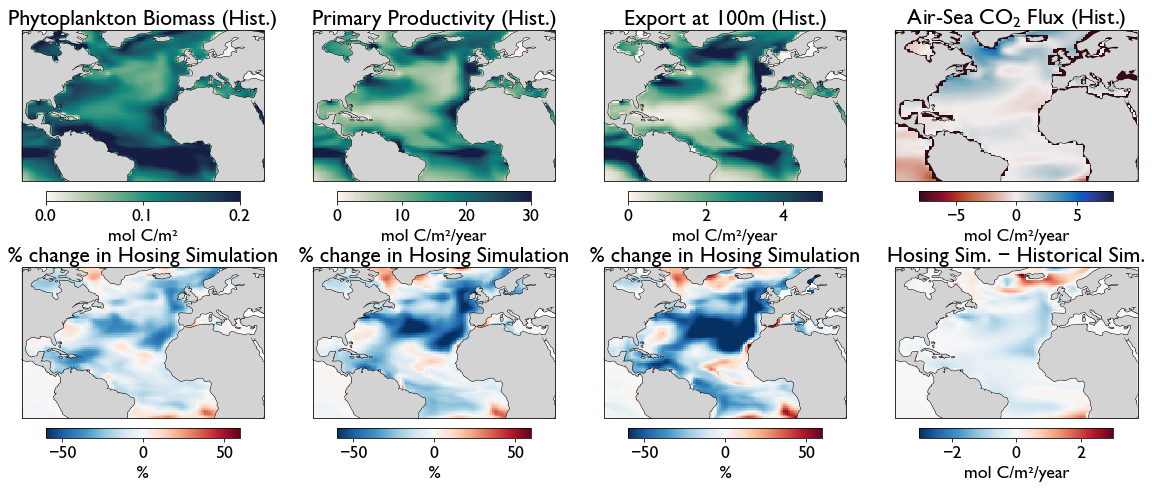

In [11]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import cmocean.cm as cm
import xarray as xr

bdir = '/gpfs/data/greenocean/users/mep22dku/clims/'
BASE = 'TOM12_TJ_OBA1'
HOSE = 'TOM12_TJ_OBH1'
BASE_diad = xr.open_dataset(f'{bdir}/{BASE}/ORCA2_1m_clim_2010_2019_diad_T_rg.nc')
HOSE_diad = xr.open_dataset(f'{bdir}/{HOSE}/ORCA2_1m_clim_2010_2019_diad_T_rg.nc')
BASE_diad['time'] = np.arange(1, 13, 1)
HOSE_diad['time'] = np.arange(1, 13, 1)

BASE_ptrc = xr.open_dataset(f'{bdir}/{BASE}/ORCA2_1m_clim_2010_2019_ptrc_T_int_rg.nc')
HOSE_ptrc = xr.open_dataset(f'{bdir}/{HOSE}/ORCA2_1m_clim_2010_2019_ptrc_T_int_rg.nc')

BASE_ptrc['PHY'] = BASE_ptrc['DIA'] + BASE_ptrc['MIX'] + BASE_ptrc['COC'] + \
                    BASE_ptrc['PHA'] + BASE_ptrc['PIC'] + BASE_ptrc['FIX']
HOSE_ptrc['PHY'] = HOSE_ptrc['DIA'] + HOSE_ptrc['MIX'] + HOSE_ptrc['COC'] + \
                    HOSE_ptrc['PHA'] + HOSE_ptrc['PIC'] + HOSE_ptrc['FIX']

days_per_month = [31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]
seconds_per_month = np.array(days_per_month) * 24 * 60 * 60
seconds_per_month_xr = xr.DataArray(seconds_per_month, dims=['time'])

BASE_diad['EXP100'] = (BASE_diad.EXP[:, 9, :, :] + BASE_diad.EXP[:, 10, :, :]) / 2
HOSE_diad['EXP100'] = (HOSE_diad.EXP[:, 9, :, :] + HOSE_diad.EXP[:, 10, :, :]) / 2

for var in ['EXP100', 'PPINT', 'Cflx']:
    BASE_diad[var][:, :, 79] = BASE_diad[var][:, :, 80].values
    HOSE_diad[var][:, :, 79] = HOSE_diad[var][:, :, 80].values

# ============ EDITABLE PARAMETERS ============
title_fontsize = 22
label_fontsize = 18
tick_fontsize = 18

lon_min = -100
lon_max = 40
lat_min = -17
lat_max = 70

phy_vmin = 0
phy_vmax = 0.2
ppint_vmin = 0
ppint_vmax = 30
exp_vmin = 0
exp_vmax = 5
cflx_vmin = -8
cflx_vmax = 8

phy_pct_max = 60
ppint_pct_max = 60
exp_pct_max = 60
cflx_diff_max = 3
# ============================================

proj = ccrs.PlateCarree()
land = cfeature.NaturalEarthFeature('physical', 'land', '110m',
                                     edgecolor='none', facecolor='lightgrey')

lats = BASE_diad.lat.values
lons = BASE_diad.lon.values

# Precompute all fields
base_phy = BASE_ptrc['PHY'].mean(dim='time') * 1000  #mol
hose_phy = HOSE_ptrc['PHY'].mean(dim='time') * 1000 #mol 
diff_phy = ((hose_phy - base_phy) / base_phy.where(base_phy != 0)) * 100

metrics = ['PPINT', 'EXP100', 'Cflx']
metric_labels = ['Primary Productivity', 'Export at 100m', 'Air-Sea CO$_2$ Flux']
metric_units = ['mol C/m²/year', 'mol C/m²/year', 'mol C/m²/year']
abs_cmaps = [cm.tempo, cm.tempo, cm.balance_r]
abs_vlims = [(ppint_vmin, ppint_vmax), (exp_vmin, exp_vmax), (cflx_vmin, cflx_vmax)]
diff_vlims = [ppint_pct_max, exp_pct_max, cflx_diff_max]
use_pct = [True, True, False]

# All labels for columns
all_labels = ['Phytoplankton Biomass'] + metric_labels
all_abs_cmaps = [cm.tempo] + abs_cmaps
all_abs_vlims = [(phy_vmin, phy_vmax)] + abs_vlims
all_diff_vlims = [phy_pct_max] + diff_vlims
all_use_pct = [True] + use_pct
all_units = ['mol C/m²'] + metric_units

# Compute base and diff fields
base_fields = [base_phy]
diff_fields = [diff_phy]

for i, metric in enumerate(metrics):
    base_yearly = (BASE_diad[metric] * seconds_per_month_xr).sum(dim='time')
    hose_yearly = (HOSE_diad[metric] * seconds_per_month_xr).sum(dim='time')
    base_fields.append(base_yearly)
    if all_use_pct[i + 1]:
        diff_fields.append(((hose_yearly - base_yearly) / base_yearly.where(base_yearly != 0)) * 100)
    else:
        diff_fields.append(hose_yearly - base_yearly)

fig, axes = plt.subplots(2, 4, figsize=(20, 8),
                         subplot_kw={'projection': proj})

for col in range(4):
    vmin_abs, vmax_abs = all_abs_vlims[col]
    dmax = all_diff_vlims[col]

    # Top row: Historical
    ax = axes[0, col]
    im = ax.pcolormesh(lons, lats, base_fields[col], transform=proj,
                        vmin=vmin_abs, vmax=vmax_abs, cmap=all_abs_cmaps[col])
    ax.coastlines()
    ax.add_feature(land, zorder=2)
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
    ax.set_title(f'{all_labels[col]} (Hist.)', fontsize=title_fontsize, fontweight='bold')
    cbar = plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.05, shrink=0.8)
    cbar.set_label(all_units[col], fontsize=label_fontsize)
    cbar.ax.tick_params(labelsize=tick_fontsize)

    # Bottom row: Difference
    ax = axes[1, col]
    im = ax.pcolormesh(lons, lats, diff_fields[col], transform=proj,
                        vmin=-dmax, vmax=dmax, cmap='RdBu_r')
    ax.coastlines()
    ax.add_feature(land, zorder=2)
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
    if all_use_pct[col]:
        ax.set_title('% change in Hosing Simulation', fontsize=title_fontsize, fontweight='bold')
        diff_unit = '%'
    else:
        ax.set_title('Hosing Sim. − Historical Sim.', fontsize=title_fontsize, fontweight='bold')
        diff_unit = all_units[col]
    cbar = plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.05, shrink=0.8)
    cbar.set_label(diff_unit, fontsize=label_fontsize)
    cbar.ax.tick_params(labelsize=tick_fontsize)

plt.tight_layout()
plt.savefig('./plts/POSTER/carbon_metrics_horizontal.png', dpi=300, bbox_inches='tight')
plt.show()

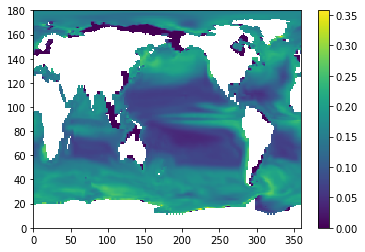

In [8]:
EXP100 = BASE_diad.EXP100.mean(dim = 'time')
PPINT = BASE_diad.PPINT.mean(dim = 'time')

w = plt.pcolormesh(EXP100/PPINT)
plt.colorbar(w)

## prov avg

In [25]:
MA = xr.open_dataset('/gpfs/home/mep22dku/scratch/AMOC-PLANKTOM/AMOC-LoP-202510/data/mask_atl.nc')
mask = xr.open_dataset('/gpfs/home/mep22dku/scratch/SOZONE/UTILS/mesh_mask3pt6_nicedims.nc')

provinces = {
    'GO': mask.csize,
    'AB': mask.csize * MA.AB,
    'HA': mask.csize * MA.HA,
    'NA': mask.csize * MA.NA,
}

BASE_diad = xr.open_dataset(f'{bdir}/{BASE}/ORCA2_1m_clim_2010_2019_diad_T.nc')
HOSE_diad = xr.open_dataset(f'{bdir}/{HOSE}/ORCA2_1m_clim_2010_2019_diad_T.nc')
BASE_diad['time'] = np.arange(1, 13, 1)
HOSE_diad['time'] = np.arange(1, 13, 1)

BASE_ptrc = xr.open_dataset(f'{bdir}/{BASE}/ORCA2_1m_clim_2010_2019_ptrc_T_int.nc')
HOSE_ptrc = xr.open_dataset(f'{bdir}/{HOSE}/ORCA2_1m_clim_2010_2019_ptrc_T_int.nc')

BASE_ptrc['PHY'] = BASE_ptrc['DIA'] + BASE_ptrc['MIX'] + BASE_ptrc['COC'] + \
                    BASE_ptrc['PHA'] + BASE_ptrc['PIC'] + BASE_ptrc['FIX']
HOSE_ptrc['PHY'] = HOSE_ptrc['DIA'] + HOSE_ptrc['MIX'] + HOSE_ptrc['COC'] + \
                    HOSE_ptrc['PHA'] + HOSE_ptrc['PIC'] + HOSE_ptrc['FIX']

BASE_diad['EXP100'] = (BASE_diad.EXP[:, 9, :, :] + BASE_diad.EXP[:, 10, :, :]) / 2
HOSE_diad['EXP100'] = (HOSE_diad.EXP[:, 9, :, :] + HOSE_diad.EXP[:, 10, :, :]) / 2


# Merge PHY into diad datasets for convenience
BASE_diad['PHY'] = BASE_ptrc['PHY']
HOSE_diad['PHY'] = HOSE_ptrc['PHY']

variables = ['PHY', 'PPINT', 'EXP100', 'Cflx']

df_base = calculate_province_means(BASE_diad, variables, provinces)
df_hose = calculate_province_means(HOSE_diad, variables, provinces)

df_base = df_base.rename(columns={'value': 'HIST'})
df_hose = df_hose.rename(columns={'value': 'HOSE'})

df = df_base.merge(df_hose[['variable', 'province', 'HOSE']], on=['variable', 'province'])
df['Diff'] = df['HOSE'] - df['HIST']
df['% Change'] = (df['Diff'] / df['HIST']) * 100

print(df.to_string(index=False))

variable province         HIST         HOSE          Diff   % Change
     PHY       GO 1.372402e-04 1.358936e-04 -1.346630e-06  -0.981221
     PHY       AB 1.377336e-04 1.294898e-04 -8.243813e-06  -5.985333
     PHY       HA 1.338117e-04 1.189968e-04 -1.481482e-05 -11.071401
     PHY       NA 1.226888e-04 1.022762e-04 -2.041259e-05 -16.637699
   PPINT       GO 4.059918e-07 3.994820e-07 -6.509802e-09  -1.603432
   PPINT       AB 4.369657e-07 4.018281e-07 -3.513752e-08  -8.041254
   PPINT       HA 5.440137e-07 4.652455e-07 -7.876818e-08 -14.479081
   PPINT       NA 3.800369e-07 2.788802e-07 -1.011567e-07 -26.617602
  EXP100       GO 6.104003e-08 5.963828e-08 -1.401750e-09  -2.296445
  EXP100       AB 7.083863e-08 6.456244e-08 -6.276192e-09  -8.859843
  EXP100       HA 9.347148e-08 8.242091e-08 -1.105057e-08 -11.822394
  EXP100       NA 5.539542e-08 3.673534e-08 -1.866008e-08 -33.685236
    Cflx       GO 1.845201e-08 1.771794e-08 -7.340743e-10  -3.978289
    Cflx       AB 2.735370e-08 2.4

In [26]:
# Load masks
MA = xr.open_dataset('/gpfs/home/mep22dku/scratch/AMOC-PLANKTOM/AMOC-LoP-202510/data/mask_atl.nc')
mask = xr.open_dataset('/gpfs/home/mep22dku/scratch/SOZONE/UTILS/mesh_mask3pt6_nicedims.nc')

# Define provinces (these are the weights!)
provinces = {
    'GO': mask.csize,
    'AB': mask.csize * MA.AB,
    'HA': mask.csize * MA.HA,
    'NA': mask.csize * MA.NA
}

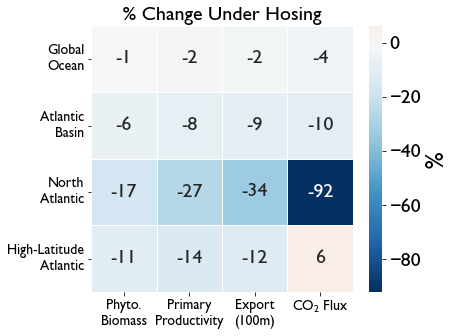

In [27]:
import seaborn as sns

pivot = df.pivot(index='province', columns='variable', values='% Change')
pivot = pivot.loc[['GO', 'AB', 'NA', 'HA'], ['PHY', 'PPINT', 'EXP100', 'Cflx']]
pivot.columns = ['Phyto.\nBiomass', 'Primary\nProductivity', 'Export\n(100m)', 'CO$_2$ Flux']
pivot.index = ['Global\nOcean', 'Atlantic\nBasin', 'North\nAtlantic', 'High-Latitude\nAtlantic']
fact = 0.8
fig, ax = plt.subplots(figsize=(8*fact, 6*fact))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='RdBu_r', center=0,
            linewidths=0.5, ax=ax, annot_kws={'fontsize': 20},
            cbar_kws={'label': '%'})
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(labelsize=14)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
ax.set_title('% Change Under Hosing', fontsize=20, fontweight='bold')
ax.figure.axes[-1].tick_params(labelsize=20)
ax.figure.axes[-1].yaxis.label.set_size(25)
plt.tight_layout()
plt.savefig('./plts/POSTER/pct_change_heatmap.jpg', dpi=300, bbox_inches='tight')
plt.show()

In [28]:
MA = xr.open_dataset('/gpfs/home/mep22dku/scratch/AMOC-PLANKTOM/AMOC-LoP-202510/data/mask_atl.nc')
mask = xr.open_dataset('/gpfs/home/mep22dku/scratch/SOZONE/UTILS/mesh_mask3pt6_nicedims.nc')

provinces = {
    'GO': mask.csize,
    'AB': mask.csize * MA.AB,
    'HA': mask.csize * MA.HA,
    'NA': mask.csize * MA.NA,
}

BASE_diad = xr.open_dataset(f'{bdir}/{BASE}/ORCA2_1m_clim_2010_2019_diad_T.nc')
HOSE_diad = xr.open_dataset(f'{bdir}/{HOSE}/ORCA2_1m_clim_2010_2019_diad_T.nc')
BASE_diad['time'] = np.arange(1, 13, 1)
HOSE_diad['time'] = np.arange(1, 13, 1)

BASE_ptrc = xr.open_dataset(f'{bdir}/{BASE}/ORCA2_1m_clim_2010_2019_ptrc_T_int.nc')
HOSE_ptrc = xr.open_dataset(f'{bdir}/{HOSE}/ORCA2_1m_clim_2010_2019_ptrc_T_int.nc')

BASE_ptrc['PHY'] = BASE_ptrc['DIA'] + BASE_ptrc['MIX'] + BASE_ptrc['COC'] + \
                    BASE_ptrc['PHA'] + BASE_ptrc['PIC'] + BASE_ptrc['FIX']
HOSE_ptrc['PHY'] = HOSE_ptrc['DIA'] + HOSE_ptrc['MIX'] + HOSE_ptrc['COC'] + \
                    HOSE_ptrc['PHA'] + HOSE_ptrc['PIC'] + HOSE_ptrc['FIX']

BASE_diad['EXP100'] = (BASE_diad.EXP[:, 9, :, :] + BASE_diad.EXP[:, 10, :, :]) / 2
HOSE_diad['EXP100'] = (HOSE_diad.EXP[:, 9, :, :] + HOSE_diad.EXP[:, 10, :, :]) / 2

BASE_diad['PHY'] = BASE_ptrc['PHY']
HOSE_diad['PHY'] = HOSE_ptrc['PHY']

variables = ['PHY', 'PPINT', 'EXP100', 'Cflx']
df_base = calculate_province_means(BASE_diad, variables, provinces)
df_hose = calculate_province_means(HOSE_diad, variables, provinces)
df_base = df_base.rename(columns={'value': 'HIST'})
df_hose = df_hose.rename(columns={'value': 'HOSE'})
df = df_base.merge(df_hose[['variable', 'province', 'HOSE']], on=['variable', 'province'])

# --- Unit conversion ---
seconds_per_year = 86400 * 365
g_per_mol        = 12
Pg_per_g         = 1e-15
conversion       = g_per_mol * Pg_per_g * seconds_per_year  # mol C/m2/s → PgC/yr

province_areas = {
    'GO': float(mask.csize.sum()),
    'AB': float((mask.csize * MA.AB).sum()),
    'HA': float((mask.csize * MA.HA).sum()),
    'NA': float((mask.csize * MA.NA).sum()),
}

flux_vars = ['PPINT', 'EXP100', 'Cflx']   # mol C/m2/s → PgC/yr
stock_vars = ['PHY']                        # mol C/m2  → PgC

for col in ['HIST', 'HOSE']:
    def convert_row(row):
        area = province_areas[row['province']]
        if row['variable'] in flux_vars:
            return row[col] * area * conversion
        elif row['variable'] in stock_vars:
            return row[col] * area * g_per_mol * Pg_per_g
        return row[col]
    df[col] = df.apply(convert_row, axis=1)

df['Diff'] = df['HOSE'] - df['HIST']
df['% Change'] = (df['Diff'] / df['HIST']) * 100

# --- Print per province ---
units = {'PHY': 'PgC', 'PPINT': 'PgC/yr', 'EXP100': 'PgC/yr', 'Cflx': 'PgC/yr'}

for prov, prov_label in [('NA', 'North Atlantic'), ('HA', 'High-Latitude Atlantic'), ('AB', 'Atlantic Basin')]:
    print(f"\n{'='*60}")
    print(f"  {prov_label}")
    print(f"{'='*60}")
    sub = df[df['province'] == prov][['variable', 'HIST', 'HOSE', 'Diff', '% Change']].copy()
    sub['units'] = sub['variable'].map(units)
    print(sub.to_string(index=False))


  North Atlantic
variable     HIST     HOSE      Diff   % Change  units
     PHY 0.000035 0.000029 -0.000006 -16.637699    PgC
   PPINT 3.391161 2.488516 -0.902646 -26.617602 PgC/yr
  EXP100 0.494307 0.327798 -0.166508 -33.685236 PgC/yr
    Cflx 0.117676 0.009196 -0.108480 -92.185287 PgC/yr

  High-Latitude Atlantic
variable     HIST     HOSE      Diff   % Change  units
     PHY 0.000017 0.000015 -0.000002 -11.071401    PgC
   PPINT 2.195185 1.877342 -0.317843 -14.479081 PgC/yr
  EXP100 0.377173 0.332582 -0.044591 -11.822394 PgC/yr
    Cflx 0.197953 0.210176  0.012223   6.174943 PgC/yr

  Atlantic Basin
variable      HIST      HOSE      Diff   % Change  units
     PHY  0.000147  0.000138 -0.000009  -5.985333    PgC
   PPINT 14.702038 13.519810 -1.182228  -8.041254 PgC/yr
  EXP100  2.383419  2.172252 -0.211167  -8.859843 PgC/yr
    Cflx  0.920336  0.826061 -0.094275 -10.243553 PgC/yr


In [29]:
AB = mask.csize*MA.AB 
print(AB[80,100])

<xarray.DataArray ()>
array(0.)
Coordinates:
    nav_lat        float32 ...
    nav_lon        float32 ...
    deptht         float32 ...
    time_centered  object ...
    time_counter   object ...


In [30]:
BASE_ptrc = xr.open_dataset(f'{bdir}/{BASE}/ORCA2_1m_clim_2010_2019_ptrc_T.nc')
BASE_ptrc_int = xr.open_dataset(f'{bdir}/{BASE}/ORCA2_1m_clim_2010_2019_ptrc_T_int.nc')

In [31]:
print(BASE_ptrc_int['DIA'][0,80,100])

print(np.sum(BASE_ptrc['DIA'][0,:,80,100].values * mask['e3t_0'][:,80,100].values))

<xarray.DataArray 'DIA' ()>
array(4.963716e-07)
Coordinates:
    nav_lat  float32 ...
    nav_lon  float32 ...
    time     int64 1
5.46428088845835e-07


In [ ]:
BASE_ptrc['DIA'][0,:,80,100]

In [ ]:
BASE_ptrc_int[0,100,100]

## fix depth integration

In [ ]:
import xarray as xr

mask = xr.open_dataset('/gpfs/home/mep22dku/scratch/SOZONE/UTILS/mesh_mask3pt6_nicedims.nc')


def integrate_depth(dataset, var_list, tmesh, suffix='_int'):
    """
    Integrate 4D variables along depth dimension to create 3D variables.
    
    Parameters
    ----------
    dataset : xr.Dataset
        Input dataset with 4D variables (time, depth, y, x)
    var_list : list of str
        Names of variables to integrate
    tmesh : xr.Dataset
        Meshmask dataset containing cell thickness (e3t_0)
    suffix : str, optional
        Suffix to append to integrated variable names (default: '_int')
        Note: This parameter is kept for backwards compatibility but is not used
        
    Returns
    -------
    xr.Dataset
        Dataset containing only integrated versions of variables from var_list
    """
    
    # Find the time dimension name
    time_dim = None
    for var in var_list:
        if var in dataset.data_vars:
            dims = dataset[var].dims
            # Assume first dimension is time
            time_dim = dims[0]
            break
    
    if time_dim is None:
        raise ValueError(f"Could not find time dimension in variables: {var_list}")
    
    # Find the depth dimension name (typically 'deptht', 'depth', 'z', etc.)
    depth_dim = None
    for var in var_list:
        if var in dataset.data_vars:
            dims = dataset[var].dims
            if len(dims) >= 2:  # Should be 4D
                depth_dim = dims[1]
            break
    
    if depth_dim is None:
        raise ValueError(f"Could not find depth dimension in variables: {var_list}")
    
    # Get cell thickness (e3t) and rename dimensions to match dataset
    e3t = tmesh['e3t_0'].copy()
    
    # Rename tmesh dimensions to match dataset dimensions
    dim_mapping = {}
    if 't' in e3t.dims:
        dim_mapping['t'] = time_dim
    if 'z' in e3t.dims:
        dim_mapping['z'] = depth_dim
    
    if dim_mapping:
        e3t = e3t.rename(dim_mapping)
    
    # Handle time dimension: squeeze if singleton, then broadcast if needed
    if time_dim in e3t.dims and e3t.sizes[time_dim] == 1:
        e3t = e3t.squeeze(time_dim, drop=True)
    
    # If e3t doesn't have the dataset's time dimension, add it
    if time_dim not in e3t.dims and time_dim in dataset.dims:
        e3t = e3t.expand_dims({time_dim: dataset[time_dim]})
    
    # Create empty output dataset
    output_ds = xr.Dataset()
    
    # Integrate each variable
    for var in var_list:
        if var not in dataset.data_vars:
            print(f"Warning: variable {var} not found in dataset")
            continue
        
        # Broadcast e3t to match variable dimensions
        e3t_broadcasted = xr.broadcast(dataset[var], e3t)[1]
        
        # Depth-integrated values
        integrated = (dataset[var] * e3t_broadcasted).sum(dim=depth_dim)
        
        # Add to output dataset without suffix
        output_ds[var] = integrated
    
    return output_ds

In [ ]:
mask.e3t_0

In [ ]:
import numpy as np
np.nanmax(mask.tmask[30,:,:])

## figure for wp2 presentation

findfont: Font family ['cursive'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'cursive' not found because none of the following families were found: Apple Chancery, Textile, Zapf Chancery, Sand, Script MT, Felipa, Comic Neue, Comic Sans MS, cursive


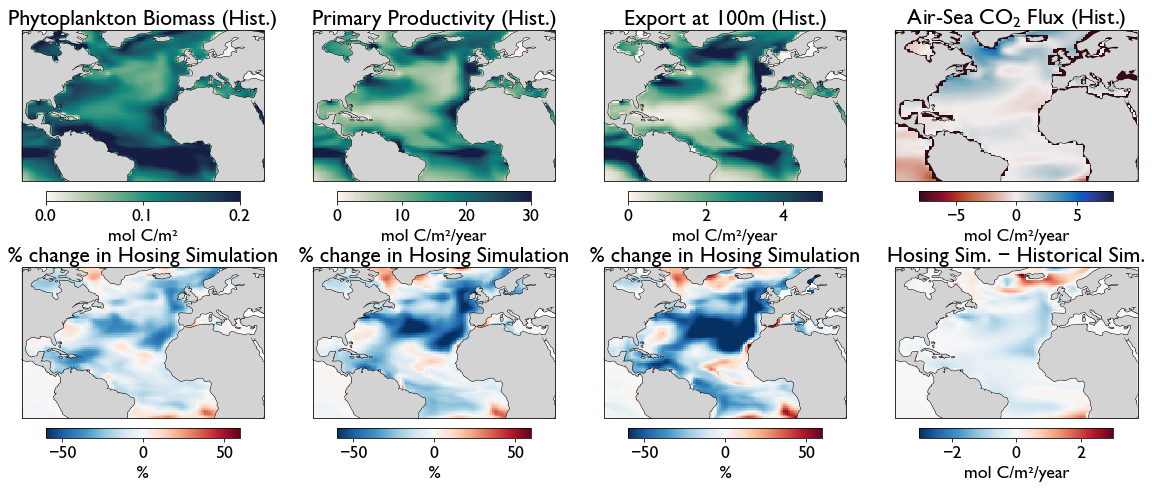

In [4]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import cmocean.cm as cm
import xarray as xr

bdir = '/gpfs/data/greenocean/users/mep22dku/clims/'
BASE = 'TOM12_TJ_OBA1'
HOSE = 'TOM12_TJ_OBH1'
BASE_diad = xr.open_dataset(f'{bdir}/{BASE}/ORCA2_1m_clim_2010_2019_diad_T_rg.nc')
HOSE_diad = xr.open_dataset(f'{bdir}/{HOSE}/ORCA2_1m_clim_2010_2019_diad_T_rg.nc')
BASE_diad['time'] = np.arange(1, 13, 1)
HOSE_diad['time'] = np.arange(1, 13, 1)

BASE_ptrc = xr.open_dataset(f'{bdir}/{BASE}/ORCA2_1m_clim_2010_2019_ptrc_T_int_rg.nc')
HOSE_ptrc = xr.open_dataset(f'{bdir}/{HOSE}/ORCA2_1m_clim_2010_2019_ptrc_T_int_rg.nc')

BASE_ptrc['PHY'] = BASE_ptrc['DIA'] + BASE_ptrc['MIX'] + BASE_ptrc['COC'] + \
                    BASE_ptrc['PHA'] + BASE_ptrc['PIC'] + BASE_ptrc['FIX']
HOSE_ptrc['PHY'] = HOSE_ptrc['DIA'] + HOSE_ptrc['MIX'] + HOSE_ptrc['COC'] + \
                    HOSE_ptrc['PHA'] + HOSE_ptrc['PIC'] + HOSE_ptrc['FIX']

days_per_month = [31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]
seconds_per_month = np.array(days_per_month) * 24 * 60 * 60
seconds_per_month_xr = xr.DataArray(seconds_per_month, dims=['time'])

BASE_diad['EXP100'] = (BASE_diad.EXP[:, 9, :, :] + BASE_diad.EXP[:, 10, :, :]) / 2
HOSE_diad['EXP100'] = (HOSE_diad.EXP[:, 9, :, :] + HOSE_diad.EXP[:, 10, :, :]) / 2

for var in ['EXP100', 'PPINT', 'Cflx']:
    BASE_diad[var][:, :, 79] = BASE_diad[var][:, :, 80].values
    HOSE_diad[var][:, :, 79] = HOSE_diad[var][:, :, 80].values

# ============ EDITABLE PARAMETERS ============
title_fontsize = 22
label_fontsize = 18
tick_fontsize = 18

lon_min = -100
lon_max = 40
lat_min = -17
lat_max = 70

phy_vmin = 0
phy_vmax = 0.2
ppint_vmin = 0
ppint_vmax = 30
exp_vmin = 0
exp_vmax = 5
cflx_vmin = -8
cflx_vmax = 8

phy_pct_max = 60
ppint_pct_max = 60
exp_pct_max = 60
cflx_diff_max = 3
# ============================================

proj = ccrs.PlateCarree()
land = cfeature.NaturalEarthFeature('physical', 'land', '110m',
                                     edgecolor='none', facecolor='lightgrey')

lats = BASE_diad.lat.values
lons = BASE_diad.lon.values

# Precompute all fields
base_phy = BASE_ptrc['PHY'].mean(dim='time') * 1000  #mol
hose_phy = HOSE_ptrc['PHY'].mean(dim='time') * 1000 #mol 
diff_phy = ((hose_phy - base_phy) / base_phy.where(base_phy != 0)) * 100

metrics = ['PPINT', 'EXP100', 'Cflx']
metric_labels = ['Primary Productivity', 'Export at 100m', 'Air-Sea CO$_2$ Flux']
metric_units = ['mol C/m²/year', 'mol C/m²/year', 'mol C/m²/year']
abs_cmaps = [cm.tempo, cm.tempo, cm.balance_r]
abs_vlims = [(ppint_vmin, ppint_vmax), (exp_vmin, exp_vmax), (cflx_vmin, cflx_vmax)]
diff_vlims = [ppint_pct_max, exp_pct_max, cflx_diff_max]
use_pct = [True, True, False]

# All labels for columns
all_labels = ['Phytoplankton Biomass'] + metric_labels
all_abs_cmaps = [cm.tempo] + abs_cmaps
all_abs_vlims = [(phy_vmin, phy_vmax)] + abs_vlims
all_diff_vlims = [phy_pct_max] + diff_vlims
all_use_pct = [True] + use_pct
all_units = ['mol C/m²'] + metric_units

# Compute base and diff fields
base_fields = [base_phy]
diff_fields = [diff_phy]

for i, metric in enumerate(metrics):
    base_yearly = (BASE_diad[metric] * seconds_per_month_xr).sum(dim='time')
    hose_yearly = (HOSE_diad[metric] * seconds_per_month_xr).sum(dim='time')
    base_fields.append(base_yearly)
    if all_use_pct[i + 1]:
        diff_fields.append(((hose_yearly - base_yearly) / base_yearly.where(base_yearly != 0)) * 100)
    else:
        diff_fields.append(hose_yearly - base_yearly)

fig, axes = plt.subplots(2, 4, figsize=(20, 8),
                         subplot_kw={'projection': proj})

for col in range(4):
    vmin_abs, vmax_abs = all_abs_vlims[col]
    dmax = all_diff_vlims[col]

    # Top row: Historical
    ax = axes[0, col]
    im = ax.pcolormesh(lons, lats, base_fields[col], transform=proj,
                        vmin=vmin_abs, vmax=vmax_abs, cmap=all_abs_cmaps[col])
    ax.coastlines()
    ax.add_feature(land, zorder=2)
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
    ax.set_title(f'{all_labels[col]} (Hist.)', fontsize=title_fontsize, fontweight='bold')
    cbar = plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.05, shrink=0.8)
    cbar.set_label(all_units[col], fontsize=label_fontsize)
    cbar.ax.tick_params(labelsize=tick_fontsize)

    # Bottom row: Difference
    ax = axes[1, col]
    im = ax.pcolormesh(lons, lats, diff_fields[col], transform=proj,
                        vmin=-dmax, vmax=dmax, cmap='RdBu_r')
    ax.coastlines()
    ax.add_feature(land, zorder=2)
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
    if all_use_pct[col]:
        ax.set_title('% change in Hosing Simulation', fontsize=title_fontsize, fontweight='bold')
        diff_unit = '%'
    else:
        ax.set_title('Hosing Sim. − Historical Sim.', fontsize=title_fontsize, fontweight='bold')
        diff_unit = all_units[col]
    cbar = plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.05, shrink=0.8)
    cbar.set_label(diff_unit, fontsize=label_fontsize)
    cbar.ax.tick_params(labelsize=tick_fontsize)

plt.tight_layout()
#plt.savefig('./plts/POSTER/carbon_metrics_horizontal.png', dpi=300, bbox_inches='tight')
plt.show()

## biomass

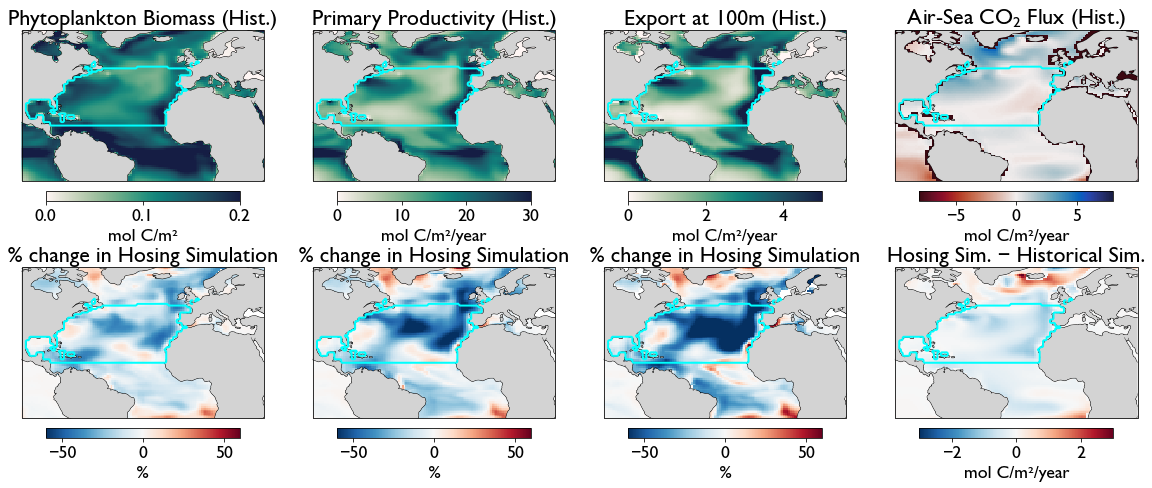

In [75]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import cmocean.cm as cm
import xarray as xr

bdir = '/gpfs/data/greenocean/users/mep22dku/clims/'
BASE = 'TOM12_TJ_OBA1'
HOSE = 'TOM12_TJ_OBH1'
BASE_diad = xr.open_dataset(f'{bdir}/{BASE}/ORCA2_1m_clim_2010_2019_diad_T_rg.nc')
HOSE_diad = xr.open_dataset(f'{bdir}/{HOSE}/ORCA2_1m_clim_2010_2019_diad_T_rg.nc')
BASE_diad['time'] = np.arange(1, 13, 1)
HOSE_diad['time'] = np.arange(1, 13, 1)

BASE_ptrc = xr.open_dataset(f'{bdir}/{BASE}/ORCA2_1m_clim_2010_2019_ptrc_T_int_rg.nc')
HOSE_ptrc = xr.open_dataset(f'{bdir}/{HOSE}/ORCA2_1m_clim_2010_2019_ptrc_T_int_rg.nc')

BASE_ptrc['PHY'] = BASE_ptrc['DIA'] + BASE_ptrc['MIX'] + BASE_ptrc['COC'] + \
                    BASE_ptrc['PHA'] + BASE_ptrc['PIC'] + BASE_ptrc['FIX']
HOSE_ptrc['PHY'] = HOSE_ptrc['DIA'] + HOSE_ptrc['MIX'] + HOSE_ptrc['COC'] + \
                    HOSE_ptrc['PHA'] + HOSE_ptrc['PIC'] + HOSE_ptrc['FIX']

days_per_month = [31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]
seconds_per_month = np.array(days_per_month) * 24 * 60 * 60
seconds_per_month_xr = xr.DataArray(seconds_per_month, dims=['time'])

BASE_diad['EXP100'] = (BASE_diad.EXP[:, 9, :, :] + BASE_diad.EXP[:, 10, :, :]) / 2
HOSE_diad['EXP100'] = (HOSE_diad.EXP[:, 9, :, :] + HOSE_diad.EXP[:, 10, :, :]) / 2

for var in ['EXP100', 'PPINT', 'Cflx']:
    BASE_diad[var][:, :, 79] = BASE_diad[var][:, :, 80].values
    HOSE_diad[var][:, :, 79] = HOSE_diad[var][:, :, 80].values

# ── Load NA mask ──────────────────────────────────────────────────────────────
MA_rg = xr.open_dataset('./data/mask_atl_rg.nc')

# ============ EDITABLE PARAMETERS ============
title_fontsize = 22
label_fontsize = 18
tick_fontsize  = 18

lon_min = -100; lon_max = 40
lat_min = -17;  lat_max = 70

phy_vmin = 0;    phy_vmax = 0.2
ppint_vmin = 0;  ppint_vmax = 30
exp_vmin = 0;    exp_vmax = 5
cflx_vmin = -8;  cflx_vmax = 8

phy_pct_max   = 60
ppint_pct_max = 60
exp_pct_max   = 60
cflx_diff_max = 3

na_contour_color    = 'cyan'
na_contour_linewidth = 2
# ============================================

proj = ccrs.PlateCarree()
land = cfeature.NaturalEarthFeature('physical', 'land', '110m',
                                     edgecolor='none', facecolor='lightgrey')

lats = BASE_diad.lat.values
lons = BASE_diad.lon.values

# Precompute all fields
base_phy  = BASE_ptrc['PHY'].mean(dim='time') * 1000
hose_phy  = HOSE_ptrc['PHY'].mean(dim='time') * 1000
diff_phy  = ((hose_phy - base_phy) / base_phy.where(base_phy != 0)) * 100

metrics       = ['PPINT', 'EXP100', 'Cflx']
metric_labels = ['Primary Productivity', 'Export at 100m', 'Air-Sea CO$_2$ Flux']
metric_units  = ['mol C/m²/year', 'mol C/m²/year', 'mol C/m²/year']
abs_cmaps     = [cm.tempo, cm.tempo, cm.balance_r]
abs_vlims     = [(ppint_vmin, ppint_vmax), (exp_vmin, exp_vmax), (cflx_vmin, cflx_vmax)]
diff_vlims    = [ppint_pct_max, exp_pct_max, cflx_diff_max]
use_pct       = [True, True, False]

all_labels    = ['Phytoplankton Biomass'] + metric_labels
all_abs_cmaps = [cm.tempo] + abs_cmaps
all_abs_vlims = [(phy_vmin, phy_vmax)] + abs_vlims
all_diff_vlims= [phy_pct_max] + diff_vlims
all_use_pct   = [True] + use_pct
all_units     = ['mol C/m²'] + metric_units

base_fields = [base_phy]
diff_fields = [diff_phy]

for i, metric in enumerate(metrics):
    base_yearly = (BASE_diad[metric] * seconds_per_month_xr).sum(dim='time')
    hose_yearly = (HOSE_diad[metric] * seconds_per_month_xr).sum(dim='time')
    base_fields.append(base_yearly)
    if all_use_pct[i + 1]:
        diff_fields.append(((hose_yearly - base_yearly) / base_yearly.where(base_yearly != 0)) * 100)
    else:
        diff_fields.append(hose_yearly - base_yearly)

        
MA_rg['NA'] = MA_rg['NA'].where(MA_rg['lat'] < 52, 0)
def add_na_contour(ax):
    ax.contour(
        MA_rg['lon'], MA_rg['lat'], MA_rg['NA'].values,
        levels=[0.5], colors=na_contour_color, linewidths=na_contour_linewidth,
        transform=proj, zorder=3
    )

fig, axes = plt.subplots(2, 4, figsize=(20, 8), subplot_kw={'projection': proj})

for col in range(4):
    vmin_abs, vmax_abs = all_abs_vlims[col]
    dmax = all_diff_vlims[col]

    # Top row: Historical
    ax = axes[0, col]
    im = ax.pcolormesh(lons, lats, base_fields[col], transform=proj,
                        vmin=vmin_abs, vmax=vmax_abs, cmap=all_abs_cmaps[col])
    ax.coastlines()
    ax.add_feature(land, zorder=2)
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
    ax.set_title(f'{all_labels[col]} (Hist.)', fontsize=title_fontsize, fontweight='bold')
    cbar = plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.05, shrink=0.8)
    cbar.set_label(all_units[col], fontsize=label_fontsize)
    cbar.ax.tick_params(labelsize=tick_fontsize)
    add_na_contour(ax)

    # Bottom row: Difference
    ax = axes[1, col]
    im = ax.pcolormesh(lons, lats, diff_fields[col], transform=proj,
                        vmin=-dmax, vmax=dmax, cmap='RdBu_r')
    ax.coastlines()
    ax.add_feature(land, zorder=2)
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
    if all_use_pct[col]:
        ax.set_title('% change in Hosing Simulation', fontsize=title_fontsize, fontweight='bold')
        diff_unit = '%'
    else:
        ax.set_title('Hosing Sim. − Historical Sim.', fontsize=title_fontsize, fontweight='bold')
        diff_unit = all_units[col]
    cbar = plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.05, shrink=0.8)
    cbar.set_label(diff_unit, fontsize=label_fontsize)
    cbar.ax.tick_params(labelsize=tick_fontsize)
    add_na_contour(ax)

plt.tight_layout()
plt.savefig('./plts/POSTER/carbon_metrics_horizontal.png', dpi=300, bbox_inches='tight')
plt.show()

In [71]:
print(MA_rg.NA.values)

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [7]:
BASE_ptrc_int = xr.open_dataset(f'{bdir}/{BASE}/ORCA2_1m_clim_2010_2019_ptrc_T_int.nc')
BASE_ptrc = xr.open_dataset(f'{bdir}/{BASE}/ORCA2_1m_clim_2010_2019_ptrc_T.nc')


import sys
sys.path.append('/gpfs/home/mep22dku/scratch/EXTRACT')
#import dis

from disimple import depth_integrate
help(depth_integrate)

res = depth_integrate(BASE_ptrc, ['DIA'])

Help on function depth_integrate in module disimple:

depth_integrate(ds, variables)
    takes an xarray and a list of variables. 
    assumes mol/L as input units, returns in mol/m2



## CALCULATE BIOMASS: bio /gpfs/home/e031/scratch/HALI_ET_EDGt

In [64]:
mask = xr.open_dataset('/gpfs/home/mep22dku/scratch/SOZONE/UTILS/mesh_mask3pt6_nicedims.nc')
atl = xr.open_dataset('/gpfs/home/mep22dku/scratch/AMOC-PLANKTOM/AMOC-LoP-202510/data/mask_atl.nc')
mask['size_NA'] = (mask.csize * atl.NA.values)

BASE_ptrc_int = xr.open_dataset(f'{bdir}/{BASE}/ORCA2_1m_clim_2010_2019_ptrc_T_int.nc')

BASE_ptrc_int = BASE_ptrc_int.mean(dim = 'time')

BASE_ptrc_int2 = BASE_ptrc_int *1000 # mmol/m2 to mol/m2

BASE_ptrc_int2['PHY'] = BASE_ptrc_int2['DIA'] + BASE_ptrc_int2['MIX'] + BASE_ptrc_int2['COC'] + \
                    BASE_ptrc_int2['PHA'] + BASE_ptrc_int2['PIC'] + BASE_ptrc_int2['FIX']

BASE_tot_Cmol_NA = np.nansum(BASE_ptrc_int2['PHY'] * mask['size_NA'])

BASE_tot_C_Pg_NA = BASE_tot_Cmol_NA * 12 / 1e15
print(f'BASE {BASE_tot_C_Pg_NA} pG')

BASE_tot_global = np.nansum(BASE_ptrc_int2['PHY'] * mask['csize']) * 12 / 1e15
print(BASE_tot_global)

mask = xr.open_dataset('/gpfs/home/mep22dku/scratch/SOZONE/UTILS/mesh_mask3pt6_nicedims.nc')
atl = xr.open_dataset('/gpfs/home/mep22dku/scratch/AMOC-PLANKTOM/AMOC-LoP-202510/data/mask_atl.nc')
mask['size_NA'] = (mask.csize * atl.NA.values)

HOSE_ptrc_int = xr.open_dataset(f'{bdir}/{HOSE}/ORCA2_1m_clim_2010_2019_ptrc_T_int.nc')

HOSE_ptrc_int = HOSE_ptrc_int.mean(dim = 'time')

HOSE_ptrc_int2 = HOSE_ptrc_int *1000 # mmol/m2 to mol/m2

HOSE_ptrc_int2['PHY'] = HOSE_ptrc_int2['DIA'] + HOSE_ptrc_int2['MIX'] + HOSE_ptrc_int2['COC'] + \
                    HOSE_ptrc_int2['PHA'] + HOSE_ptrc_int2['PIC'] + HOSE_ptrc_int2['FIX']

HOSE_tot_Cmol_NA = np.nansum(HOSE_ptrc_int2['PHY'] * mask['size_NA'])

HOSE_tot_C_Pg_NA = HOSE_tot_Cmol_NA * 12 / 1e15
print(f'HOSE {HOSE_tot_C_Pg_NA} pG')

HOSE_tot_global = np.nansum(HOSE_ptrc_int2['PHY'] * mask['csize']) * 12 / 1e15
print(HOSE_tot_global)

BASE 0.03471529535191574 pG
0.5943446795236568
HOSE 0.02893946905363806 pG
0.5885128435855586


HOSE 0.02893946905363806 pG
0.5885128435855586


## calculaate provincial totals -- works. 

In [63]:
mask = xr.open_dataset('/gpfs/home/mep22dku/scratch/SOZONE/UTILS/mesh_mask3pt6_nicedims.nc')
atl = xr.open_dataset('/gpfs/home/mep22dku/scratch/AMOC-PLANKTOM/AMOC-LoP-202510/data/mask_atl.nc')
mask['size_NA'] = (mask.csize * atl.NA.values)

s_per_year   = 365.25 * 86400
molar_mass_C = 12.011
g_per_Pg     = 1e15

def to_petagrams_per_year(data_molCm2s, csize):
    total = (data_molCm2s * csize).sum()
    return float(total * s_per_year * molar_mass_C / g_per_Pg)


BASE_diad = xr.open_dataset(f'{bdir}/{BASE}/ORCA2_1m_clim_2010_2019_diad_T.nc')
HOSE_diad = xr.open_dataset(f'{bdir}/{HOSE}/ORCA2_1m_clim_2010_2019_diad_T.nc')
BASE_diad['EXP100'] = (BASE_diad.EXP[:, 9, :, :] + BASE_diad.EXP[:, 10, :, :]) / 2
HOSE_diad['EXP100'] = (HOSE_diad.EXP[:, 9, :, :] + HOSE_diad.EXP[:, 10, :, :]) / 2

metrics       = ['PPINT', 'EXP100', 'Cflx']
metric_labels = ['Primary Productivity', 'Export at 100m', 'Air-Sea CO₂ Flux']
regions       = {'Global': mask['csize'], 'North Atlantic': mask['size_NA']}



for ds_name, ds in [('BASE', BASE_diad), ('HOSE', HOSE_diad)]:
    print(f'\n{ds_name}')
    for m, label in zip(metrics, metric_labels):
        data_mean = ds[m].mean('time')
        for region, rmask in regions.items():
            pg = to_petagrams_per_year(data_mean, rmask)
            print(f'  {label} [{region}]: {pg:.4f} Pg C/yr')


BASE
  Primary Productivity [Global]: 55.5362 Pg C/yr
  Primary Productivity [North Atlantic]: 3.3966 Pg C/yr
  Export at 100m [Global]: 8.3498 Pg C/yr
  Export at 100m [North Atlantic]: 0.4951 Pg C/yr
  Air-Sea CO₂ Flux [Global]: 2.5241 Pg C/yr
  Air-Sea CO₂ Flux [North Atlantic]: 0.1179 Pg C/yr

HOSE
  Primary Productivity [Global]: 54.6457 Pg C/yr
  Primary Productivity [North Atlantic]: 2.4925 Pg C/yr
  Export at 100m [Global]: 8.1580 Pg C/yr
  Export at 100m [North Atlantic]: 0.3283 Pg C/yr
  Air-Sea CO₂ Flux [Global]: 2.4237 Pg C/yr
  Air-Sea CO₂ Flux [North Atlantic]: 0.0092 Pg C/yr
